# **Fine-Tune W2V2-Bert for low-resource ASR with 🤗 Transformers**

***New (01/2024)***: *This blog post is strongly inspired by "[Fine-tuning XLS-R on Multi-Lingual ASR](https://huggingface.co/blog/fine-tune-xlsr-wav2vec2)"* and ["Fine-tuning MMS Adapter Models for Multi-Lingual ASR"](https://huggingface.co/blog/mms_adapters).

## Introduction

Last month, MetaAI released [Wav2Vec2-BERT](https://huggingface.co/docs/transformers/main/en/model_doc/wav2vec2-bert), as a building block of their [Seamless Communication](https://ai.meta.com/research/seamless-communication/), a family of AI translation models.

[Wav2Vec2-BERT](https://huggingface.co/docs/transformers/main/en/model_doc/wav2vec2-bert) is the result of a series of improvements based on an original model: **Wav2Vec2**, a pre-trained model for Automatic Speech Recognition (ASR) released in [September 2020](https://ai.facebook.com/blog/wav2vec-20-learning-the-structure-of-speech-from-raw-audio/) by *Alexei Baevski, Michael Auli, and Alex Conneau*.  With as little as 10 minutes of labeled audio data, Wav2Vec2 could be fine-tuned to achieve 5% word-error rate performance on the [LibriSpeech](https://huggingface.co/datasets/librispeech_asr) dataset, demonstrating for the first time low-resource transfer learning for ASR.

Following a series of multilingual improvements ([XLSR](https://huggingface.co/docs/transformers/model_doc/xlsr_wav2vec2), [XLS-R](https://huggingface.co/docs/transformers/model_doc/xls_r) and [MMS](https://huggingface.co/docs/transformers/model_doc/mms)), Wav2Vec2-BERT is a 580M-parameters versatile audio model that has been pre-trained on **4.5M** hours of unlabeled audio data covering **more than 143 languages**. For comparison, **XLS-R** used almost **half a million** hours of audio data in **128 languages** and **MMS** checkpoints were pre-trained on more than **half a million hours of audio** in over **1,400 languages**. Boosting to millions of hours enables Wav2Vec2-BERT to achieve even more competitive results in speech-related tasks, whatever the language.

To use it for ASR, Wav2Vec2-BERT can be fine-tuned using Connectionist Temporal Classification (CTC), which is an algorithm that is used to train neural networks for sequence-to-sequence problems, such as ASR and handwriting recognition. We highly recommend reading the well-written blog post [*Sequence Modeling with CTC (2017)*](https://distill.pub/2017/ctc/) by Awni Hannun, to learn more about the CTC algorithm.

The aim of this notebook is to give you all the elements you need to train Wav2Vec2-BERT model - more specifically the pre-trained checkpoint [**facebook/w2v-bert-2.0**](https://huggingface.co/facebook/w2v-bert-2.0) - on ASR tasks, using open-source tools and models. It first presents the complete pre-processing pipeline, then performs a little fine-tuning of the W2V2-BERT. The final section gathers training tips from Hugging Face experts to scale-up CTC training.

For demonstration purposes, we fine-tune the model on the low resource Mongolian ASR dataset of [Common Voice 16.0](https://huggingface.co/datasets/mozilla-foundation/common_voice_16_0) that contains *ca.* 14h of validated training data.

## Motivation

[Whisper](https://huggingface.co/blog/fine-tune-whisper#introduction) is a suite of ASR models, commonly accepted as the best performing models for the ASR task. It provides state-of-the-art performance for English ASR, while being well suited to multilingual fine-tuning from limited resources.

However, when it comes to "resource-poor" languages such as Mongolian, Whisper performs poorly, as seen in section D.2.2 of the [Whisper paper](https://cdn.openai.com/papers/whisper.pdf) - Mongolian or Malayalam achieved over 100% WER at every Whisper checkpoint. The checkpoint available also have a limited vocabulary and therefore cannot be fine-tuned on a language whose alphabet does not overlap with this vocabulary.

In addition, Whisper is a sequence-to-sequence model that performs ASR autoregressively, making it inherently "slow".

Faced with limited resources - both in terms of training data availability and inference constraints - more "frugal" models are needed. In this case, Wav2Vec2-BERT is just the thing.

**Wav2Vec2-BERT** predicts ASR in a single pass, making it much faster than Whisper. As this notebook will show, it requires **little data** to achieve **competitive performance**, is **easily adaptable** to any alphabet, and is **more resource-efficient**.

In fact, it achieves **similar WER performance** on Mongolian ASR compared with [Whisper-large-v3](https://huggingface.co/openai/whisper-large-v3) after similar fine-tuning, while being over **8x faster** and **2.5x more resource-efficient**.


## Notebook Setup

First, let's try to get a good GPU in our colab! With Google Colab's free version it's sadly becoming much harder to get access to a good GPU. With Google Colab Pro, however, one should easily get either a V100 or P100 GPU.

In [1]:
gpu_info = !nvidia-smi
gpu_info = '\n'.join(gpu_info)
if gpu_info.find('failed') >= 0:
  print('Not connected to a GPU')
else:
  print(gpu_info)

Wed Apr 29 10:28:06 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 590.57                 Driver Version: 591.86         CUDA Version: 13.1     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3080        On  |   00000000:07:00.0  On |                  N/A |
|  0%   41C    P8             24W /  370W |    1124MiB /  10240MiB |     35%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

Before we start, let's install `datasets` and `transformers`. Also, we need `accelerate` for training, `torchaudio` to load audio files and `jiwer` to evaluate our fine-tuned model using the [word error rate (WER)](https://huggingface.co/metrics/wer) metric ${}^1$.

In [ ]:
# %%capture
# !pip install datasets
# !pip install transformers
# !pip install torchaudio
# !pip install jiwer
# !pip install accelerate -U

In [2]:
import torch

In [3]:
print(f"CUDA Available: {torch.cuda.is_available()}")
print(f"Using GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'NONE'}")
print(f"Torch Version: {torch.__version__}")

CUDA Available: True
Using GPU: NVIDIA GeForce RTX 3080
Torch Version: 2.8.0+cu126


We strongly suggest to upload your training checkpoints directly to the [🤗 Hub](https://huggingface.co/) while training. The [🤗 Hub](https://huggingface.co/) provides:

- Integrated version control: you can be sure that no model checkpoint is lost during training.
- Tensorboard logs: track important metrics over the course of training.
- Model cards: document what a model does and its intended use cases.
- Community: an easy way to share and collaborate with the community!

To do so, you have to store your authentication token from the Hugging Face website (sign up [here](https://huggingface.co/join) if you haven't already!). This is done by entering your Hub authentication token when prompted below. Find your Hub authentication token [here](https://huggingface.co/settings/tokens):

In [ ]:
from huggingface_hub import notebook_login

notebook_login()


Then you need to install Git-LFS to upload your model checkpoints:

In [ ]:
%%capture
!apt install git-lfs




---

${}^1$ In the [paper](https://arxiv.org/pdf/2006.13979.pdf), the model was evaluated using the phoneme error rate (PER), but by far the most common metric in ASR is the word error rate (WER). To keep this notebook as general as possible we decided to evaluate the model using WER.

## Prepare Data, Tokenizer, Feature Extractor

ASR models transcribe speech to text, which means that we both need a feature extractor that processes the speech signal to the model's input format, *e.g.* a feature vector, and a tokenizer that processes the model's output format to text.

In 🤗 Transformers, the Wav2Vec2-BERT model is thus accompanied by both a tokenizer, called [Wav2Vec2CTCTokenizer](https://huggingface.co/transformers/master/model_doc/wav2vec2.html#wav2vec2ctctokenizer), and a feature extractor, called [SeamlessM4TFeatureExtractor](https://huggingface.co/docs/transformers/v4.36.1/en/model_doc/seamless_m4t#transformers.SeamlessM4TFeatureExtractor) that the model shares with the [first](https://huggingface.co/docs/transformers/main/en/model_doc/seamless_m4t) and [second](https://huggingface.co/docs/transformers/main/en/model_doc/seamless_m4_v2t) versions of Seamless-M4T, as they all process audio in the same way.

Let's start by creating the tokenizer to decode the predicted output classes to the output transcription.

### Create `Wav2Vec2CTCTokenizer`

Remember that Wav2Vec2-like models fine-tuned on CTC transcribe an audio file with a single forward pass by first processing the audio input into a sequence of processed context representations and then using the final vocabulary output layer to classify each context representation to a character that represents the transcription.

The output size of this layer corresponds to the number of tokens in the vocabulary, and therefore only on the labeled dataset used for fine-tuning. So in the first step, we will take a look at the chosen dataset of Common Voice and define a vocabulary based on the transcriptions.

For this notebook, we will use [Common Voice's 16.0 dataset](https://huggingface.co/datasets/mozilla-foundation/common_voice_16_0) for Mongolian. Mongolian corresponds to the language code `"mn"`.

Now we can use 🤗 Datasets' simple API to download the data. The dataset name is `"mozilla-foundation/common_voice_16_0"`, the configuration name corresponds to the language code, which is `"mn"` in our case.

**Note**: Before being able to download the dataset, you have to access it by logging into your Hugging Face account, going on the [dataset repo page](https://huggingface.co/datasets/mozilla-foundation/common_voice_16_0) and clicking on:

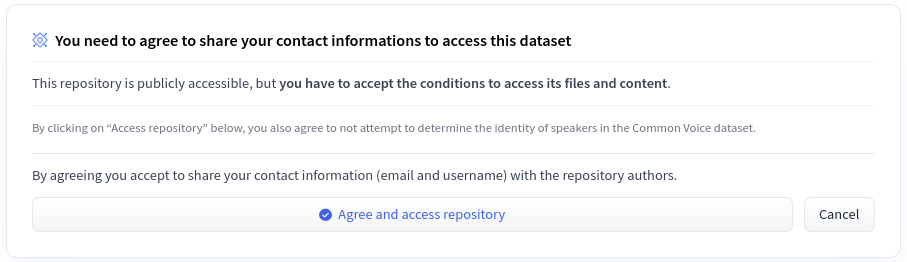

Common Voice has many different splits including `invalidated`, which refers to data that was not rated as "clean enough" to be considered useful. In this notebook, we will only make use of the splits `"train"`, `"validation"` and `"test"`.

Because the Mongolian dataset is so small, we will merge both the validation and training data into a training dataset and only use the test data for validation.

### Combined Data Loading

In [4]:
from datasets import load_dataset, concatenate_datasets, Dataset
import librosa
import numpy as np
import os
import re
from pathlib import Path

# --- Updated Paths for WSL ---
# We use forward slashes and the /mnt/c/ prefix
cv_data_path = "/mnt/c/Users/Ian/Documents/TeziTesting/dataset/cv-corpus-24.0-2025-12-05/mt"
masri_root = "/mnt/c/Users/Ian/Documents/TeziTesting/MASRI_HEADSET_v2/MASRI_HEADSET_v2"

# --- 1. Load Common Voice ---
# Note: Using os.path.join or f-strings with forward slashes is safer in Linux
dataset_dict = load_dataset("csv", data_files={
    "train": f"{cv_data_path}/train.tsv",
    "validation": f"{cv_data_path}/dev.tsv",
    "test": f"{cv_data_path}/test.tsv"
}, delimiter="\t")

# --- 2. Load and Format MASRI ---
def load_masri_as_dataset():
    # os.path.join in WSL will correctly use forward slashes
    paths_file = os.path.join(masri_root, "files", "MASRI_HEADSET_v2.paths")
    trans_file = os.path.join(masri_root, "files", "MASRI_HEADSET_v2.trans")
    
    with open(paths_file, "r", encoding="utf-8") as f:
        # Clean up Windows carriage returns (\r) just in case
        raw_paths = [line.strip().replace("./", "") + ".wav" for line in f.readlines()]
    
    with open(trans_file, "r", encoding="utf-8") as f:
        raw_transcriptions = [line.strip().split(" ", 1)[1] for line in f.readlines()]
        
        # Preposition cleaning logic remains the same
        cleaned_transcriptions = [
            re.sub(r"\b([bfmsxlt]')\s+", r"\1", t, flags=re.IGNORECASE) 
            for t in raw_transcriptions
        ]

    masri_dict = {
        "path": raw_paths,
        "sentence": cleaned_transcriptions,
        "client_id": ["masri_user"] * len(raw_paths),
        "sentence_id": [None] * len(raw_paths),
        "sentence_domain": [None] * len(raw_paths),
        "up_votes": [0] * len(raw_paths),
        "down_votes": [0] * len(raw_paths),
        "age": [None] * len(raw_paths),
        "gender": [None] * len(raw_paths),
        "accents": [None] * len(raw_paths),
        "variant": [None] * len(raw_paths),
        "locale": ["mt"] * len(raw_paths),
        "segment": [None] * len(raw_paths)
    }
    return Dataset.from_dict(masri_dict)

masri_ds = load_masri_as_dataset()

# --- 3. Concatenate Training Data ---
common_voice_train = concatenate_datasets([
    dataset_dict["train"], 
    dataset_dict["validation"], 
    masri_ds
])
common_voice_test = dataset_dict["test"]

# --- 4. Fix Paths for Both Sources ---
def prepare_paths(batch):
    full_paths = []
    for p in batch["path"]:
        if p.startswith("speech"):
            # Result: /mnt/c/Users/Ian/.../speech/audio.wav
            full_paths.append(os.path.join(masri_root, p))
        else:
            # Result: /mnt/c/Users/Ian/.../clips/common_voice_mt_123.mp3
            full_paths.append(os.path.join(cv_data_path, "clips", p))
            
    batch["path"] = full_paths
    batch["audio"] = full_paths 
    return batch

common_voice_train = common_voice_train.map(prepare_paths, batched=True)
common_voice_test = common_voice_test.map(prepare_paths, batched=True)

# --- 5. Decode Audio ---
# No changes needed here; librosa handles Linux paths perfectly!
def decode_audio(batch):
    speech_array, _ = librosa.load(batch["path"], sr=16000)
    batch["audio"] = {
        "path": batch["path"],
        "array": np.array(speech_array, dtype=np.float32),
        "sampling_rate": 16000
    }
    return batch

common_voice_train = common_voice_train.map(decode_audio)
common_voice_test = common_voice_test.map(decode_audio)

### Common Voice Only Loading

In [30]:
from datasets import load_dataset, concatenate_datasets
import os
import librosa

data_path = "/mnt/c/Users/Ian/Documents/TeziTesting/dataset/cv-corpus-24.0-2025-12-05/mt"

# 1. Load all three splits (Train, Dev, Test)
dataset_dict = load_dataset("csv", data_files={
    "train": f"{data_path}/train.tsv",
    "validation": f"{data_path}/dev.tsv",
    "test": f"{data_path}/test.tsv"
}, delimiter="\t")

# 2. Replicate your old 'train+validation' concatenation
common_voice_train = concatenate_datasets([dataset_dict["train"], dataset_dict["validation"]])
common_voice_test = dataset_dict["test"]

# 3. Fix the paths AND create the placeholder for the audio column
def prepare_paths(batch):
    # Prepend the full path to the filenames
    full_paths = [os.path.join(data_path, "clips", p) for p in batch["path"]]
    batch["path"] = full_paths
    # We create the 'audio' column as a copy of the path for now
    # This keeps your code from crashing when you try to 'remove_columns(["audio"])' later
    batch["audio"] = full_paths 
    return batch

common_voice_train = common_voice_train.map(prepare_paths, batched=True)
common_voice_test = common_voice_test.map(prepare_paths, batched=True)

In [31]:
import librosa
import numpy as np # Add this import at the top

def decode_audio(batch):
    speech_array, _ = librosa.load(batch["path"], sr=16000)
    batch["audio"] = {
        "path": batch["path"],
        "array": np.array(speech_array, dtype=np.float32), # This creates the .shape attribute
        "sampling_rate": 16000
    }
    return batch

# Apply to the datasets. This will take a minute or two.
common_voice_train = common_voice_train.map(decode_audio)
common_voice_test = common_voice_test.map(decode_audio)

In [4]:
print(common_voice_train[0])

{'client_id': '47d501b79a8382bf868895f4ab0762c78bdf94e3e05e387a88ea56c9533b1f5e84b841593d79b75fbbd2439c5005be0d2c21f4b2870b23202c1b6de7fb5ed19f', 'path': '/mnt/c/Users/Ian/Documents/TeziTesting/dataset/cv-corpus-24.0-2025-12-05/mt/clips/common_voice_mt_21170200.mp3', 'sentence_id': '091fe0c199b7f50dc5c471d8d87b21814fcec5110f4445897a355271b6dd65a7', 'sentence': 'Ilek ma tagħmel blind date?', 'sentence_domain': None, 'up_votes': 2, 'down_votes': 1, 'age': 'thirties', 'gender': 'male_masculine', 'accents': None, 'variant': None, 'locale': 'mt', 'segment': None, 'audio': {'array': [-1.7280399333685637e-11, -1.8417267710901797e-11, -6.821210263296962e-12, -4.547473508864641e-12, 2.546585164964199e-11, -2.2737367544323206e-11, 2.3646862246096134e-11, -7.275957614183426e-12, 3.637978807091713e-12, -3.456079866737127e-11, -2.9103830456733704e-11, -6.366462912410498e-12, -2.7284841053187847e-12, 9.094947017729282e-13, 2.2737367544323206e-12, 1.4551915228366852e-11, -6.366462912410498e-12, -7.27

### New Data Loading

In [1]:
import os
import pandas as pd
from pathlib import Path
from datasets import Dataset, concatenate_datasets

# --- Configuration ---
DATA_ROOT = Path.home() / "MalteseProject" / "Data"

def get_audio_path(root_dir, filename, is_nested=False):
    if not filename or filename == "None":
        return None
        
    root_dir = Path(root_dir)
    # Ensure filename has the .wav extension for searching
    search_name = filename if filename.lower().endswith(".wav") else f"{filename}.wav"
    
    if not is_nested:
        direct_path = root_dir / search_name
        return str(direct_path) if direct_path.exists() else None
    
    # Recursive search for MASRI (searching through gender/speaker folders)
    # glob is faster than rglob if we know the pattern, but rglob is safest
    for p in root_dir.rglob(search_name):
        return str(p)
            
    return None

def process_subset(folder_path, source_type, subset_name):
    data_list = []
    folder_path = Path(folder_path)
    
    def safe_str(val):
        return str(val).strip() if pd.notna(val) else ""

    # --- 1 & 2: MASRI / CV (Train & Dev) ---
    if subset_name in ["Train", "Dev"]:
        if source_type == "MASRI":
            csv_name = "masriTrain.csv" if subset_name == "Train" else "masriDev.csv"
            df = pd.read_csv(folder_path / csv_name)
            audio_dir = folder_path / "audio files"
            is_nested = True
            sent_col, id_col = 'transcription_mt', 'filename' # Handle MASRI casing
            # Check if MASRI uses 'Filename' with capital F
            if id_col not in df.columns and 'Filename' in df.columns:
                id_col = 'Filename'
        else: # CV
            csv_name = "cvTrain.csv" if subset_name == "Train" else "cvDev.csv"
            df = pd.read_csv(folder_path / csv_name)
            audio_dir = folder_path / "audio files"
            is_nested = False
            sent_col, id_col = 'sentence_mt', 'filename'

        for _, row in df.iterrows():
            fname = safe_str(row[id_col])
            path = get_audio_path(audio_dir, fname, is_nested=is_nested)
            
            if path:
                data_list.append({
                    "path": path, 
                    "sentence_id": fname,
                    "sentence": safe_str(row[sent_col]), 
                    "sentence_domain": source_type, 
                    "variant": "MT", 
                    "audio": path
                })

    # --- 3: MASRI Test ---
    elif source_type == "MASRI" and subset_name == "Test":
        trans_path = folder_path / "transcription.trans"
        audio_dir = folder_path / "speech"
        
        if trans_path.exists():
            with open(trans_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split(" ", 1)
                    if len(parts) < 2: continue
                    file_id = parts[0]
                    fname = f"{file_id}.wav"
                    path = get_audio_path(audio_dir, fname, is_nested=True)
                    if path:
                        data_list.append({
                            "path": path, "sentence_id": file_id,
                            "sentence": safe_str(parts[1]), 
                            "sentence_domain": "MASRI", "variant": "MT", "audio": path
                        })

    # --- 4: CV Test ---
    elif source_type == "CV" and subset_name == "Test":
        csv_path = folder_path / "FileSequenceCV.csv"
        df = pd.read_csv(csv_path)
        audio_dir = folder_path / "speech"
        corr_col = "If MT-Sentence needs correction, put it here"
        
        for _, row in df.iterrows():
            # Use correction if it exists, else use standard 'sentence'
            final_sent = row[corr_col] if pd.notna(row[corr_col]) and str(row[corr_col]).strip() != "" else row['sentence']
            fname = safe_str(row['path'])
            path = get_audio_path(audio_dir, fname, is_nested=False)
            
            if path:
                data_list.append({
                    "path": path, "sentence_id": fname,
                    "sentence": safe_str(final_sent), 
                    "sentence_domain": "CommonVoice", "variant": "MT", "audio": path
                })

    return Dataset.from_list(data_list)

In [2]:
# --- Process Datasets ---
common_voice_train = concatenate_datasets([
    process_subset(f"{DATA_ROOT}/Train/MASRI Train Release 202501", "MASRI", "Train"),
    process_subset(f"{DATA_ROOT}/Train/CV Train Release 202501", "CV", "Train")
])

common_voice_dev = concatenate_datasets([
    process_subset(f"{DATA_ROOT}/Dev/MASRI Dev Release 202501", "MASRI", "Dev"),
    process_subset(f"{DATA_ROOT}/Dev/CV Dev Release 202501", "CV", "Dev")
])

common_voice_test = concatenate_datasets([
    process_subset(f"{DATA_ROOT}/Test/MASRI", "MASRI", "Test"),
    process_subset(f"{DATA_ROOT}/Test/CV", "CV", "Test")
])

In [3]:
# --- 5. Decode Audio ---
import librosa
import numpy as np

def decode_audio_batched(batch):
    # Process the whole batch in a list comprehension
    audio_data = []
    for path in batch["path"]:
        speech_array, _ = librosa.load(path, sr=16000)
        audio_data.append({
            "path": path,
            "array": np.array(speech_array, dtype=np.float32),
            "sampling_rate": 16000
        })
    batch["audio"] = audio_data
    return batch

# Applying the decoding to all three sets
common_voice_train = common_voice_train.map(decode_audio_batched, batched=True)
common_voice_dev = common_voice_dev.map(decode_audio_batched, batched=True)
common_voice_test = common_voice_test.map(decode_audio_batched, batched=True)

print(f"✅ Loaded and Decoded with Librosa! Train: {len(common_voice_train)} samples.")

Map:   0%|          | 0/8886 [00:00<?, ? examples/s]

Map:   0%|          | 0/1883 [00:00<?, ? examples/s]

Map:   0%|          | 0/1892 [00:00<?, ? examples/s]

✅ Loaded and Decoded with Librosa! Train: 8886 samples.


In [16]:
import librosa

def calculate_duration(dataset):
    # Sum up durations of all paths in the 'audio' column
    total_seconds = sum(librosa.get_duration(path=x) for x in dataset['audio'])
    
    total_hours = total_seconds / 3600
    print(f"Total Duration: {total_seconds:.2f} seconds")
    print(f"Total Duration: {total_hours:.2f} hours")
    
    return total_hours


calculate_duration(common_voice_test)

Total Duration: 5657.74 seconds
Total Duration: 1.57 hours


1.5715933333333323

In [1]:
### Masri Only

import os
import pandas as pd
from pathlib import Path
from datasets import Dataset, concatenate_datasets
import librosa
import numpy as np

# --- Configuration ---
DATA_ROOT = Path.home() / "MalteseProject" / "Data"

def get_audio_path(root_dir, filename, is_nested=False):
    if not filename or filename == "None":
        return None
        
    root_dir = Path(root_dir)
    search_name = filename if filename.lower().endswith(".wav") else f"{filename}.wav"
    
    if not is_nested:
        direct_path = root_dir / search_name
        return str(direct_path) if direct_path.exists() else None
    
    for p in root_dir.rglob(search_name):
        return str(p)
            
    return None

def process_subset(folder_path, source_type, subset_name):
    data_list = []
    folder_path = Path(folder_path)
    
    def safe_str(val):
        return str(val).strip() if pd.notna(val) else ""

    # --- MASRI (Train & Dev) ---
    if subset_name in ["Train", "Dev"] and source_type == "MASRI":
        csv_name = "masriTrain.csv" if subset_name == "Train" else "masriDev.csv"
        df = pd.read_csv(folder_path / csv_name)
        audio_dir = folder_path / "audio files"
        is_nested = True
        sent_col, id_col = 'transcription_mt', 'filename'
        
        if id_col not in df.columns and 'Filename' in df.columns:
            id_col = 'Filename'

        for _, row in df.iterrows():
            fname = safe_str(row[id_col])
            path = get_audio_path(audio_dir, fname, is_nested=is_nested)
            
            if path:
                data_list.append({
                    "path": path, 
                    "sentence_id": fname,
                    "sentence": safe_str(row[sent_col]), 
                    "sentence_domain": source_type, 
                    "variant": "MT", 
                    "audio": path
                })

    # --- MASRI Test ---
    elif source_type == "MASRI" and subset_name == "Test":
        trans_path = folder_path / "transcription.trans"
        audio_dir = folder_path / "speech"
        
        if trans_path.exists():
            with open(trans_path, "r", encoding="utf-8") as f:
                for line in f:
                    parts = line.strip().split(" ", 1)
                    if len(parts) < 2: continue
                    file_id = parts[0]
                    fname = f"{file_id}.wav"
                    path = get_audio_path(audio_dir, fname, is_nested=True)
                    if path:
                        data_list.append({
                            "path": path, "sentence_id": file_id,
                            "sentence": safe_str(parts[1]), 
                            "sentence_domain": "MASRI", "variant": "MT", "audio": path
                        })

    return Dataset.from_list(data_list)

# --- Process Only MASRI Datasets ---
masri_train = process_subset(f"{DATA_ROOT}/Train/MASRI Train Release 202501", "MASRI", "Train")
masri_dev = process_subset(f"{DATA_ROOT}/Dev/MASRI Dev Release 202501", "MASRI", "Dev")
masri_test = process_subset(f"{DATA_ROOT}/Test/MASRI", "MASRI", "Test")

In [2]:
# --- Decode Audio ---
def decode_audio_batched(batch):
    audio_data = []
    for path in batch["path"]:
        speech_array, _ = librosa.load(path, sr=16000)
        audio_data.append({
            "path": path,
            "array": np.array(speech_array, dtype=np.float32),
            "sampling_rate": 16000
        })
    batch["audio"] = audio_data
    return batch

# Applying decoding (Note: names updated to masri_*)
masri_train = masri_train.map(decode_audio_batched, batched=True)
masri_dev = masri_dev.map(decode_audio_batched, batched=True)
masri_test = masri_test.map(decode_audio_batched, batched=True)

print(f"✅ Loaded MASRI! Train: {len(masri_train)}, Dev: {len(masri_dev)}, Test: {len(masri_test)}")

Map:   0%|          | 0/4963 [00:00<?, ? examples/s]

Map:   0%|          | 0/648 [00:00<?, ? examples/s]

Map:   0%|          | 0/668 [00:00<?, ? examples/s]

✅ Loaded MASRI! Train: 4963, Dev: 648, Test: 668


In [1]:
import os
import pandas as pd
from pathlib import Path
from datasets import Dataset
import librosa
import numpy as np

# --- Configuration ---
DATA_ROOT = Path.home() / "MalteseProject" / "Data"

def get_audio_path(root_dir, filename, is_nested=False):
    if not filename or filename == "None":
        return None
    root_dir = Path(root_dir)
    search_name = filename if filename.lower().endswith(".wav") else f"{filename}.wav"
    
    if not is_nested:
        direct_path = root_dir / search_name
        return str(direct_path) if direct_path.exists() else None
    
    for p in root_dir.rglob(search_name):
        return str(p)
    return None

def process_cv_subset(folder_path, subset_name):
    data_list = []
    folder_path = Path(folder_path)
    
    def safe_str(val):
        return str(val).strip() if pd.notna(val) else ""

    # --- Train & Dev Logic ---
    if subset_name in ["Train", "Dev"]:
        csv_name = "cvTrain.csv" if subset_name == "Train" else "cvDev.csv"
        df = pd.read_csv(folder_path / csv_name)
        audio_dir = folder_path / "audio files"
        
        for _, row in df.iterrows():
            fname = safe_str(row['filename'])
            path = get_audio_path(audio_dir, fname, is_nested=False)
            if path:
                data_list.append({
                    "path": path, 
                    "sentence_id": fname,
                    "sentence": safe_str(row['sentence_mt']), 
                    "sentence_domain": "CommonVoice", 
                    "variant": "MT", 
                    "audio": path
                })

    # --- Test Logic (with Correction Column) ---
    elif subset_name == "Test":
        csv_path = folder_path / "FileSequenceCV.csv"
        df = pd.read_csv(csv_path)
        audio_dir = folder_path / "speech"
        corr_col = "If MT-Sentence needs correction, put it here"
        
        for _, row in df.iterrows():
            # logic: Use correction if it exists, otherwise use standard 'sentence'
            final_sent = row[corr_col] if pd.notna(row[corr_col]) and str(row[corr_col]).strip() != "" else row['sentence']
            fname = safe_str(row['path'])
            path = get_audio_path(audio_dir, fname, is_nested=False)
            
            if path:
                data_list.append({
                    "path": path, 
                    "sentence_id": fname,
                    "sentence": safe_str(final_sent), 
                    "sentence_domain": "CommonVoice", 
                    "variant": "MT", 
                    "audio": path
                })

    return Dataset.from_list(data_list)

# --- 1. Load the Splits Individually ---
# These are now kept as separate Dataset objects
common_voice_train = process_cv_subset(DATA_ROOT / "Train" / "CV Train Release 202501", "Train")
common_voice_dev = process_cv_subset(DATA_ROOT / "Dev" / "CV Dev Release 202501", "Dev")
common_voice_test = process_cv_subset(DATA_ROOT / "Test" / "CV", "Test")

# --- Verification ---
print(f"Train size: {len(common_voice_train)}")
print(f"Dev size: {len(common_voice_dev)}")
print(f"Test size: {len(common_voice_test)}")

Train size: 3923
Dev size: 1235
Test size: 1224


In [ ]:
# --- 3. Decode Audio ---
def decode_audio(batch):
    # Note: Using librosa to match your target format
    speech_array, _ = librosa.load(batch["path"], sr=16000)
    batch["audio"] = {
        "path": batch["path"],
        "array": np.array(speech_array, dtype=np.float32),
        "sampling_rate": 16000
    }
    return batch

# Apply decoding (this processes one row at a time as per your old script)
common_voice_train = common_voice_train.map(decode_audio)
common_voice_test = common_voice_test.map(decode_audio)

print(f"✅ Loaded CV! Train+Dev: {len(common_voice_train)}, Test: {len(common_voice_test)}")

In [2]:
def add_duration(example):
    # librosa.get_duration reads the header without loading the full waveform
    example["duration"] = librosa.get_duration(path=example["path"])
    return example

# Apply to your datasets
cv_train_with_duration = common_voice_train.map(add_duration)

# Calculate Average
avg_duration = np.mean(cv_train_with_duration["duration"])
print(f"Average Duration: {avg_duration:.2f} seconds")
print(f"Total Hours: {sum(cv_train_with_duration['duration']) / 3600:.2f}")

Map:   0%|          | 0/3923 [00:00<?, ? examples/s]

Average Duration: 4.76 seconds
Total Hours: 5.19


In [13]:
# # --- Cast to Audio ---
# # Important: We assign back to the variable so the change persists
# common_voice_train = train_dataset.cast_column("audio", Audio(sampling_rate=16000))
# common_voice_dev = dev_dataset.cast_column("audio", Audio(sampling_rate=16000))
# common_voice_test = test_dataset.cast_column("audio", Audio(sampling_rate=16000))

# print(f"✅ Success! Train: {len(common_voice_train)} | Dev: {len(common_voice_dev)} | Test: {len(common_voice_test)}")

In [ ]:
# # Apply the decoding to the whole dataset
# # We use 'remove_columns' to get rid of the old string paths 
# # so we only keep the processed audio and the text.
# common_voice_train = dataset["train"].map(speech_file_to_array_fn, remove_columns=dataset["train"].column_names)
# common_voice_test = dataset["test"].map(speech_file_to_array_fn, remove_columns=dataset["test"].column_names)

# # Verify the final structure
# print(common_voice_train[0])

Map: 100%|██████████| 1660/1660 [00:19<00:00, 85.39 examples/s] 

{'audio': {'array': [-3.183231456205249e-12, -2.7284841053187847e-11, 4.547473508864641e-13, -5.4569682106375694e-12, 1.3642420526593924e-11, -1.5916157281026244e-11, 7.275957614183426e-12, 1.8189894035458565e-12, -1.0913936421275139e-11, -3.001332515850663e-11, -2.546585164964199e-11, -7.275957614183426e-12, -1.318767317570746e-11, 3.637978807091713e-12, -2.2737367544323206e-12, 1.4551915228366852e-11, -2.7284841053187847e-12, -5.4569682106375694e-12, -2.319211489520967e-11, -3.637978807091713e-12, -6.366462912410498e-12, -1.0913936421275139e-11, -1.2732925824820995e-11, -1.2278178473934531e-11, -7.275957614183426e-12, 6.366462912410498e-12, -6.366462912410498e-12, -1.8189894035458565e-11, -5.4569682106375694e-12, -2.7284841053187847e-11, -3.637978807091713e-12, -3.456079866737127e-11, -1.2732925824820995e-11, -6.366462912410498e-12, 7.275957614183426e-12, -9.094947017729282e-13, -5.4569682106375694e-12, 5.4569682106375694e-12, -2.7284841053187847e-12, -3.637978807091713e-12, -4.54747

In [ ]:
# from datasets import load_dataset, Audio

# # Define your local path
# data_path = r"C:\Users\Ian\Documents\TeziTesting\dataset\cv-corpus-24.0-2025-12-05\mt"

# # 1. Load the TSV files
# dataset = load_dataset("csv", data_files={
#     "train": f"{data_path}/train.tsv",
#     "validation": f"{data_path}/dev.tsv",
#     "test": f"{data_path}/test.tsv"
# }, delimiter="\t")

In [ ]:
# # 2. Replicate your old 'train+validation' split
# from datasets import concatenate_datasets
# common_voice_train = concatenate_datasets([dataset["train"], dataset["validation"]])
# common_voice_test = dataset["test"]

In [ ]:
# # 3. CRITICAL: Prepend the path to the audio filenames
# # Common Voice TSVs usually have a column 'path' that just says 'common_voice_mt_123.mp3'
# # We need to make it 'C:/.../mt/clips/common_voice_mt_123.mp3'
# def add_full_path(example):
#     example["audio"] = f"{data_path}/clips/{example['path']}"
#     return example

# common_voice_train = common_voice_train.map(add_full_path)
# common_voice_test = common_voice_test.map(add_full_path)

# # 4. Cast to Audio feature so it decodes automatically
# common_voice_train = common_voice_train.cast_column("audio", Audio(sampling_rate=16000, decode=True)) #Added decode = true because of librosa (I changed to librosa instad of torchcodec)
# common_voice_test = common_voice_test.cast_column("audio", Audio(sampling_rate=16000, decode=True))

In [ ]:
# from datasets import load_dataset, load_metric, Audio

# common_voice_train = load_dataset("mozilla-foundation/common_voice_16_0", "mn", split="train+validation", use_auth_token=True)
# common_voice_test = load_dataset("mozilla-foundation/common_voice_16_0", "mn", split="test", use_auth_token=True)

ImportError: cannot import name 'load_metric' from 'datasets' (c:\Users\Ian\anaconda3\envs\w2v2_asr\lib\site-packages\datasets\__init__.py)

Many ASR datasets only provide the target text, `'sentence'` for each audio array `'audio'` and file `'path'`. Common Voice actually provides much more information about each audio file, such as the `'accent'`, etc. Keeping the notebook as general as possible, we only consider the transcribed text for fine-tuning.

In [5]:
print(f"Current columns: {common_voice_train.column_names}")

Current columns: ['path', 'sentence_id', 'sentence', 'sentence_domain', 'variant', 'audio']


In [ ]:
common_voice_train = common_voice_train.remove_columns(["accents", "age", "client_id", "down_votes", "gender", "locale", "segment", "up_votes"])
common_voice_test = common_voice_test.remove_columns(["accents", "age", "client_id", "down_votes", "gender", "locale", "segment", "up_votes"])

Let's write a short function to display some random samples of the dataset and run it a couple of times to get a feeling for the transcriptions.

In [3]:
from datasets import ClassLabel
import random
import pandas as pd
from IPython.display import display, HTML

def show_random_elements(dataset, num_examples=10):
    assert num_examples <= len(dataset), "Can't pick more elements than there are in the dataset."
    picks = []
    for _ in range(num_examples):
        pick = random.randint(0, len(dataset)-1)
        while pick in picks:
            pick = random.randint(0, len(dataset)-1)
        picks.append(pick)

    df = pd.DataFrame(dataset[picks])
    display(HTML(df.to_html()))

In [4]:
show_random_elements(common_voice_train.remove_columns(["path", "audio"]), num_examples=10)

NameError: name 'common_voice_train' is not defined

Alright! The transcriptions look fairly clean. Having translated the transcribed sentences, it seems that the language corresponds more to written-out text than noisy dialogue. This makes sense considering that [Common Voice](https://huggingface.co/datasets/mozilla-foundation/common_voice_16_0) is a crowd-sourced read speech corpus.

We can see that the transcriptions contain some special characters, such as `,.?!;:`. Without a language model, it is much harder to classify speech chunks to such special characters because they don't really correspond to a characteristic sound unit. *E.g.*, the letter `"s"` has a more or less clear sound, whereas the special character `"."` does not.
Also in order to understand the meaning of a speech signal, it is usually not necessary to include special characters in the transcription.

Let's simply remove all characters that don't contribute to the meaning of a word and cannot really be represented by an acoustic sound and normalize the text.

In [ ]:
import re
chars_to_remove_regex = '[\,\?\.\!\;\:\"\“\%\‘\”\�\»\«]'

def remove_special_characters(batch):
    # remove special characters
    batch["sentence"] = re.sub(chars_to_remove_regex, '', batch["sentence"]).lower()

    return batch

In [13]:
common_voice_train = common_voice_train.map(remove_special_characters)
common_voice_test = common_voice_test.map(remove_special_characters)

Map:   0%|          | 0/3535 [00:00<?, ? examples/s]

Map:   0%|          | 0/1660 [00:00<?, ? examples/s]

In [5]:
import sys
import re
from pathlib import Path

masri_root = str(Path(".").resolve() / "MASRI")

if masri_root not in sys.path:
    sys.path.append(masri_root)

# Importing tokeniser
try:
    from masri.tokenise.tokenise import MTWordTokenizer
    tokenizer = MTWordTokenizer()
    print("MASRI Tokenizer loaded successfully!")
except ImportError as e:
    print(f"Failed to load MASRI: {e}")


# 3. Define the cleaning function
chars_to_remove_regex = r'[\d\.,\?\!\`\_\;\:\"\“\%\‘\”\\»\«]' #Removed ` because only appears twice.

def process_maltese_text(batch):
    # Initial cleaning (remove unwanted symbols/punctuation)
    clean_text = re.sub(chars_to_remove_regex, '', batch["sentence"]).lower()

    # Define your Normalization Mapping
    # This maps rare accented characters to their base versions
    # mapping = {#
    #     'á': 'a',
    #     'è': 'e',
    #     'é': 'e',
    #     'ì': 'i',
    #     'ò': 'o',
    #     'ù': 'u',
    #     'ć': 'ċ'  

    # }

    # 3. Apply the mapping
    # for char, replacement in mapping.items():
    #     clean_text = clean_text.replace(char, replacement)

    # 4. Use MASRI tokenizer to handle Maltese specifics (clitics, etc.)
    # Note: Ensure the tokenizer is initialized outside this function
    tokens = tokenizer.tokenize(clean_text)
    
    # 5. Re-join into a clean string for ASR training
    batch["sentence"] = " ".join(tokens)
    return batch

MASRI Tokenizer loaded successfully!


In [6]:
# 4. Apply to your datasets
masri_train = masri_train.map(process_maltese_text)
masri_test = masri_test.map(process_maltese_text)
masri_dev = masri_dev.map(process_maltese_text)

Map:   0%|          | 0/4963 [00:00<?, ? examples/s]

Map:   0%|          | 0/668 [00:00<?, ? examples/s]

Map:   0%|          | 0/648 [00:00<?, ? examples/s]

In [7]:
# 4. Apply to your datasets
common_voice_train = common_voice_train.map(process_maltese_text)
common_voice_test = common_voice_test.map(process_maltese_text)
common_voice_dev = common_voice_dev.map(process_maltese_text)

Map:   0%|          | 0/8886 [00:00<?, ? examples/s]

Map:   0%|          | 0/1892 [00:00<?, ? examples/s]

Map:   0%|          | 0/1883 [00:00<?, ? examples/s]

Let's look at the processed text labels again.

In [9]:
show_random_elements(common_voice_test.remove_columns(["path","audio"]))

,sentence_id,sentence,sentence_domain,variant
0,MSRTS_F_17_TS_00053,dan induna bis- sunnetti ta' magħha fl- istess żmien il- professur vincenzo lawrenza,MASRI,MT
1,MSRTS_F_09_TS_00005,u għadu għal qalbi ħafna u nikkoraġġixxi ' il min huwa interessat fil- letteratura maltija,MASRI,MT
2,common_voice_mt_21240768.wav,l- inċident seħħ ilbieraħ waranofsinhar,CommonVoice,MT
3,MSRTS_F_04_TS_00009,madoff hux dejjem b' xi ħaġa jien,MASRI,MT
4,common_voice_mt_21178572.wav,l- afrika ta' fuq ma tistax tieħu r- ruħ,CommonVoice,MT
5,MSRTS_M_17_TS_00005,meta ġabarhom nistgħu inkunu nafu għax intom dawk sibtuhom qegħdin flimkien il- ħdax- il sunnett it- taljan bit-,MASRI,MT
6,MSRTS_M_04_TS_00019,ġieli kien ikellimna xi xi ħadd ftit iktar adult insomma jipprova jdaħħlilna ftit sens f' moħħna peress li kont l- iskola qed niftakar,MASRI,MT
7,common_voice_mt_21257307.wav,dan bil- konsegwenza li l- kunsilli lokali jispiċċaw jaffaċċjaw kritika inġusta huma stess,CommonVoice,MT
8,common_voice_mt_21209174.wav,il- bomba splodiet f' ħin meta kienet għaddejja karozza tal- linja,CommonVoice,MT
9,common_voice_mt_21209006.wav,beda jirbaħ il- gwerer kollha,CommonVoice,MT


In CTC, it is common to classify speech chunks into letters, so we will do the same here.
Let's extract all distinct letters of the training and test data and build our vocabulary from this set of letters.

We write a mapping function that concatenates all transcriptions into one long transcription and then transforms the string into a set of chars.
It is important to pass the argument `batched=True` to the `map(...)` function so that the mapping function has access to all transcriptions at once.

In [11]:
def extract_all_chars(batch):
  all_text = " ".join(batch["sentence"])
  vocab = list(set(all_text))
  return {"vocab": [vocab], "all_text": [all_text]}

In [12]:
vocab_train = common_voice_train.map(extract_all_chars, batched=True, batch_size=-1, keep_in_memory=True, remove_columns=common_voice_train.column_names)
vocab_test = common_voice_test.map(extract_all_chars, batched=True, batch_size=-1, keep_in_memory=True, remove_columns=common_voice_test.column_names)

Map:   0%|          | 0/5158 [00:00<?, ? examples/s]

Map:   0%|          | 0/1224 [00:00<?, ? examples/s]

Now, we create the union of all distinct letters in the training dataset and test dataset and convert the resulting list into an enumerated dictionary.

In [13]:
vocab_list = list(set(vocab_train["vocab"][0]) | set(vocab_test["vocab"][0]))

In [14]:
vocab_dict = {v: k for k, v in enumerate(sorted(vocab_list))}
vocab_dict

{' ': 0,
 "'": 1,
 '-': 2,
 'a': 3,
 'b': 4,
 'c': 5,
 'd': 6,
 'e': 7,
 'f': 8,
 'g': 9,
 'h': 10,
 'i': 11,
 'j': 12,
 'k': 13,
 'l': 14,
 'm': 15,
 'n': 16,
 'o': 17,
 'p': 18,
 'q': 19,
 'r': 20,
 's': 21,
 't': 22,
 'u': 23,
 'v': 24,
 'w': 25,
 'x': 26,
 'y': 27,
 'z': 28,
 'à': 29,
 'ċ': 30,
 'ġ': 31,
 'ħ': 32,
 'ż': 33}

Cleaning up a dataset is a back-and-forth process that needs to be done with care.

Looking at the separate letters in the training and test datasets, and after discussing them with a native speaker of the target language (thanks [Mishig](https://github.com/mishig25)  for taking a look), we can see Latin characters that we are going to remove for two reasons:
1. the CTC algorithm benefits from reduced vocabulary size
2. in this example, we are concentrating entirely on the Mongolian alphabet.

In [ ]:
# def remove_latin_characters(batch):
#     batch["sentence"] = re.sub(r'[a-z]+', '', batch["sentence"])
#     return batch

# # remove latin characters
# common_voice_train = common_voice_train.map(remove_latin_characters)
# common_voice_test = common_voice_test.map(remove_latin_characters)

# # extract unique characters again
# vocab_train = common_voice_train.map(extract_all_chars, batched=True, batch_size=-1, keep_in_memory=True, remove_columns=common_voice_train.column_names)
# vocab_test = common_voice_test.map(extract_all_chars, batched=True, batch_size=-1, keep_in_memory=True, remove_columns=common_voice_test.column_names)
# vocab_list = list(set(vocab_train["vocab"][0]) | set(vocab_test["vocab"][0]))

# vocab_dict = {v: k for k, v in enumerate(sorted(vocab_list))}
# vocab_dict

Map:   0%|          | 0/4041 [00:00<?, ? examples/s]

Map:   0%|          | 0/1893 [00:00<?, ? examples/s]

Map:   0%|          | 0/4041 [00:00<?, ? examples/s]

Map:   0%|          | 0/1893 [00:00<?, ? examples/s]

{' ': 0,
 'а': 1,
 'б': 2,
 'в': 3,
 'г': 4,
 'д': 5,
 'е': 6,
 'ж': 7,
 'з': 8,
 'и': 9,
 'й': 10,
 'к': 11,
 'л': 12,
 'м': 13,
 'н': 14,
 'о': 15,
 'п': 16,
 'р': 17,
 'с': 18,
 'т': 19,
 'у': 20,
 'ф': 21,
 'х': 22,
 'ц': 23,
 'ч': 24,
 'ш': 25,
 'ъ': 26,
 'ы': 27,
 'ь': 28,
 'э': 29,
 'ю': 30,
 'я': 31,
 'ё': 32,
 'ү': 33,
 'ө': 34}

Cool, we see that all letters of the alphabet occur in the dataset (which is not really surprising) and we also extracted the special character `" "`. Note that we did not exclude this special character because:

The model has to learn to predict when a word is finished or else the model prediction would always be a sequence of chars which would make it impossible to separate words from each other.

One should always keep in mind that pre-processing is a very important step before training your model. E.g., we don't want our model to differentiate between `a` and `A` just because we forgot to normalize the data. The difference between `a` and `A` does not depend on the "sound" of the letter at all, but more on grammatical rules - *e.g.* use a capitalized letter at the beginning of the sentence. So it is sensible to remove the difference between capitalized and non-capitalized letters so that the model has an easier time learning to transcribe speech.




To make it clearer that `" "` has its own token class, we give it a more visible character `|`. In addition, we also add an "unknown" token so that the model can later deal with characters not encountered in Common Voice's training set.

In [20]:
vocab_dict["|"] = vocab_dict[" "]
del vocab_dict[" "]

Finally, we also add a padding token that corresponds to CTC's "*blank token*".


The "blank token" is a core component of the CTC algorithm. For more information, please take a look at the "Alignment" section [here](https://distill.pub/2017/ctc/).

In [21]:
vocab_dict["[UNK]"] = len(vocab_dict)
vocab_dict["[PAD]"] = len(vocab_dict)
len(vocab_dict)

36

Cool, now our vocabulary is complete and consists of 37 tokens, which means that the linear layer that we will add on top of the pretrained W2V-BERT checkpoint will have an output dimension of 37.

Let's now save the vocabulary as a json file.

In [20]:
import json
with open('vocab.json', 'w') as vocab_file:
    json.dump(vocab_dict, vocab_file)

In a final step, we use the json file to load the vocabulary into an instance of the `Wav2Vec2CTCTokenizer` class.

In [20]:
from transformers import Wav2Vec2CTCTokenizer

tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("./", unk_token="[UNK]", pad_token="[PAD]", word_delimiter_token="|")

If one wants to re-use the just created tokenizer with the fine-tuned model of this notebook, it is strongly advised to upload the `tokenizer` to the [🤗 Hub](https://huggingface.co/). Let's call the repo to which we will upload the files
`"w2v-bert-2.0-mongolian-colab-CV16.0"`:

In [ ]:
repo_name = "w2v-bert-2.0-mongolian-colab-CV16.0"

and upload the tokenizer to the [🤗 Hub](https://huggingface.co/).

In [33]:
tokenizer.push_to_hub(repo_name)

NameError: name 'repo_name' is not defined

Great, you can see the just created repository under `https://huggingface.co/<your-username>/w2v-bert-2.0-mongolian-colab-CV16.0`

### Create `SeamlessM4TFeatureExtractor`

The role of the `SeamlessM4TFeatureExtractor` is to prepare the raw audio input in a format that the model can "understand". It therefore maps the sequence of one-dimensional amplitude values (aka the raw audio input) to a two-dimensional matrix of log-mel spectrogram values. The latter encodes the signal frequency information as a function of time. See [this section](https://huggingface.co/learn/audio-course/chapter1/audio_data#the-frequency-spectrum) from the Audio Transformers course to learn more about spectrograms and why they are important.

Unlike the tokenizer, the feature extractor doesn't need to be "learned" from the data, so we can load it directly from the [initial model checkpoint](https://huggingface.co/facebook/w2v-bert-2.0).


In [21]:
from transformers import SeamlessM4TFeatureExtractor

feature_extractor = SeamlessM4TFeatureExtractor(feature_size=80, num_mel_bins=80, sampling_rate=16000, padding_value=0.0)

Great, W2V-BERT's feature extraction pipeline is thereby fully defined!

For improved user-friendliness, the feature extractor and tokenizer are *wrapped* into a single `Wav2Vec2BertProcessor` class so that one only needs a `model` and `processor` object.

In [22]:
from transformers import Wav2Vec2BertProcessor

processor = Wav2Vec2BertProcessor(feature_extractor=feature_extractor, tokenizer=tokenizer)

In [ ]:
processor.push_to_hub(repo_name)

Next, we can prepare the dataset.

### Preprocess Data

So far, we have not looked at the actual values of the speech signal but just the transcription. In addition to `sentence`, our datasets include two more column names `path` and `audio`. `path` states the absolute path of the audio file. Let's take a look.


In [ ]:
# !pip install torchcodec

   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   --------- ------------------------------ 0.5/2.2 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 2.2/2.2 MB 10.4 MB/s  0:00:00


In [28]:
common_voice_train[0]["path"]

'/home/ian/MalteseProject/Data/Train/MASRI Train Release 202501/audio files/female/F_01/MSRHS_F_01_P02U001_0001.wav'

W2V-BERT expects the input in the format of a 1-dimensional array of 16 kHz. This means that the audio file has to be loaded and resampled.

 Thankfully, `datasets` does this automatically by calling the other column `audio`. Let try it out.

In [45]:
common_voice_train[0]["audio"]

{'array': [0.005828857421875,
  0.008819580078125,
  0.006988525390625,
  0.0079345703125,
  0.00732421875,
  0.007232666015625,
  0.007720947265625,
  0.00823974609375,
  0.00909423828125,
  0.0087890625,
  0.008087158203125,
  0.008056640625,
  0.007354736328125,
  0.008270263671875,
  0.007354736328125,
  0.00726318359375,
  0.0076904296875,
  0.007781982421875,
  0.00775146484375,
  0.0067138671875,
  0.0074462890625,
  0.008056640625,
  0.006805419921875,
  0.006378173828125,
  0.00738525390625,
  0.0069580078125,
  0.007537841796875,
  0.00689697265625,
  0.005828857421875,
  0.00543212890625,
  0.007080078125,
  0.006988525390625,
  0.006072998046875,
  0.006317138671875,
  0.005828857421875,
  0.006439208984375,
  0.006072998046875,
  0.005462646484375,
  0.0057373046875,
  0.00689697265625,
  0.005645751953125,
  0.005126953125,
  0.005615234375,
  0.005706787109375,
  0.00634765625,
  0.004180908203125,
  0.005126953125,
  0.005340576171875,
  0.0047607421875,
  0.00527954101


Great, we can see that the audio file has automatically been loaded. This is thanks to the new [`"Audio"` feature](https://huggingface.co/docs/datasets/package_reference/main_classes.html?highlight=audio#datasets.Audio) introduced in `datasets == 4.13.3`, which loads and resamples audio files on-the-fly upon calling.

In the example above we can see that the audio data is loaded with a sampling rate of 48kHz whereas Wav2Vec2-BERT was pre-trained at a sampling rate of 16kHz. The sampling rate plays an important role in that it defines how many data points of the speech signal are measured per second. Therefore, sampling with a higher sampling rate results in a better approximation of the *real* speech signal but also necessitates more values per second.

A pre-trained checkpoint expects its input data to have been sampled more or less from the same distribution as the data it was trained on. The same speech signals sampled at two different rates have a very different distribution, *e.g.*, doubling the sampling rate results in data points being twice as long. Thus,
before fine-tuning a pre-trained checkpoint of an ASR model, it is crucial to verify that the sampling rate of the data that was used to pre-train the model matches the sampling rate of the dataset used to fine-tune the model.

In [ ]:
# common_voice_train = common_voice_train.cast_column("audio", Audio(sampling_rate=16_000))
# common_voice_test = common_voice_test.cast_column("audio", Audio(sampling_rate=16_000))

NameError: name 'Audio' is not defined

Let's take a look at `"audio"` again.

In [29]:
common_voice_train[0]["audio"]

{'array': [0.005828857421875,
  0.008819580078125,
  0.006988525390625,
  0.0079345703125,
  0.00732421875,
  0.007232666015625,
  0.007720947265625,
  0.00823974609375,
  0.00909423828125,
  0.0087890625,
  0.008087158203125,
  0.008056640625,
  0.007354736328125,
  0.008270263671875,
  0.007354736328125,
  0.00726318359375,
  0.0076904296875,
  0.007781982421875,
  0.00775146484375,
  0.0067138671875,
  0.0074462890625,
  0.008056640625,
  0.006805419921875,
  0.006378173828125,
  0.00738525390625,
  0.0069580078125,
  0.007537841796875,
  0.00689697265625,
  0.005828857421875,
  0.00543212890625,
  0.007080078125,
  0.006988525390625,
  0.006072998046875,
  0.006317138671875,
  0.005828857421875,
  0.006439208984375,
  0.006072998046875,
  0.005462646484375,
  0.0057373046875,
  0.00689697265625,
  0.005645751953125,
  0.005126953125,
  0.005615234375,
  0.005706787109375,
  0.00634765625,
  0.004180908203125,
  0.005126953125,
  0.005340576171875,
  0.0047607421875,
  0.00527954101

This seemed to have worked! Let's listen to a couple of audio files to better understand the dataset and verify that the audio was correctly loaded.

**Note**: *You can click the following cell a couple of times to listen to different speech samples.*

In [30]:
import IPython.display as ipd
import numpy as np
import random

rand_int = random.randint(0, len(common_voice_train)-1)

print(common_voice_train[rand_int]["sentence"])
ipd.Audio(data=common_voice_train[rand_int]["audio"]["array"], autoplay=True, rate=16000)

jinħabbu bil- bosta għarajjes flimkien u mat- tabib callus ma tantx tista' tiċċajta


It seems like the data is now correctly loaded and resampled.

It can be heard, that the speakers change along with their speaking rate, accent, and background environment, etc. Overall, the recordings sound acceptably clear though, which is to be expected from a crowd-sourced read speech corpus.

Let's do a final check that the data is correctly prepared, by printing the shape of the speech input, its transcription, and the corresponding sampling rate.

**Note**: *You can click the following cell a couple of times to verify multiple samples.*

In [ ]:
# rand_int = random.randint(0, len(common_voice_train)-1)

# print("Target text:", common_voice_train[rand_int]["sentence"])
# print("Input array shape:", common_voice_train[rand_int]["audio"]["array"].shape)
# print("Sampling rate:", common_voice_train[rand_int]["audio"]["sampling_rate"])

In [50]:
import random
import numpy as np

rand_int = random.randint(0, len(common_voice_train)-1)

# Get the array data
audio_data = common_voice_train[rand_int]["audio"]["array"]

print("Target text:", common_voice_train[rand_int]["sentence"])
# We wrap it in np.array here just to check the shape
print("Input array shape:", np.array(audio_data).shape) 
print("Sampling rate:", common_voice_train[rand_int]["audio"]["sampling_rate"])

Target text: il- fieragħ tal- fizzjal imħawwad b' dak kollu li kien ġralu wara li ħallieha laqqas kien jiftakar iżjed fil- laqgħa li kellu qawl il- lejl ma' marjetta
Input array shape: (128521,)
Sampling rate: 16000


Good! Everything looks fine - the data is a 1-dimensional array, the sampling rate always corresponds to 16kHz, and the target text is normalized.

Finally, we can leverage `Wav2Vec2BertProcessor` to process the data to the format expected by `Wav2Vec2BertForCTC` for training. To do so let's make use of Dataset's [`map(...)`](https://huggingface.co/docs/datasets/package_reference/main_classes.html?highlight=map#datasets.DatasetDict.map) function.

First, we load and resample the audio data, simply by calling `batch["audio"]`.
Second, we extract the `input_features` from the loaded audio file. In our case, the `Wav2Vec2BertProcessor` creates a more complex representation as the raw waveform, known as [Log-Mel feature extraction](https://en.wikipedia.org/wiki/Mel-frequency_cepstrum).
Third, we encode the transcriptions to label ids.


In [31]:
def prepare_dataset(batch):
    audio = batch["audio"]
    batch["input_features"] = processor(audio["array"], sampling_rate=audio["sampling_rate"]).input_features[0]
    batch["input_length"] = len(batch["input_features"])

    batch["labels"] = processor(text=batch["sentence"]).input_ids
    return batch

Let's apply the data preparation function to all examples.

In [32]:
common_voice_train = common_voice_train.map(prepare_dataset, remove_columns=common_voice_train.column_names)
common_voice_test = common_voice_test.map(prepare_dataset, remove_columns=common_voice_test.column_names)

Map:   0%|          | 0/8886 [00:00<?, ? examples/s]

Map:   0%|          | 0/1892 [00:00<?, ? examples/s]

**Note**: `datasets` automatically takes care of audio loading and resampling. If you wish to implement your own costumized data loading/sampling, feel free to just make use of the `"path"` column instead and disregard the `"audio"` column.

Awesome, now we are ready to start training!

## Training

The data is processed so that we are ready to start setting up the training pipeline. We will make use of 🤗's [Trainer](https://huggingface.co/transformers/master/main_classes/trainer.html?highlight=trainer) for which we essentially need to do the following:

- Define a data collator. In contrast to most NLP models, W2V-BERT has a much larger input length than output length. Given the large input sizes, it is much more efficient to pad the training batches dynamically meaning that all training samples should only be padded to the longest sample in their batch and not the overall longest sample. Therefore, fine-tuning W2V-BERT requires a special padding data collator, which we will define below.

- Evaluation metric. During training, the model should be evaluated on the word error rate. We should define a `compute_metrics` function accordingly

- Load a pretrained checkpoint. We need to load a pretrained checkpoint and configure it correctly for training.

- Define the training configuration.

After having fine-tuned the model, we will correctly evaluate it on the test data and verify that it has indeed learned to correctly transcribe speech.

### Set-up Trainer

Let's start by defining the data collator. The code for the data collator was copied from [this example](https://github.com/huggingface/transformers/blob/7e61d56a45c19284cfda0cee8995fb552f6b1f4e/examples/pytorch/speech-recognition/run_speech_recognition_ctc.py#L219).

Without going into too many details, in contrast to the common data collators, this data collator treats the `input_features` and `labels` differently and thus applies to separate padding functions on them. This is necessary because in speech input and output are of different modalities meaning that they should not be treated by the same padding function.
Analogous to the common data collators, the padding tokens in the labels with `-100` so that those tokens are **not** taken into account when computing the loss.

In [33]:
import torch

from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Union

@dataclass
class DataCollatorCTCWithPadding:
    processor: Wav2Vec2BertProcessor
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # split inputs and labels since they have to be of different lenghts and need
        # different padding methods
        input_features = [{"input_features": feature["input_features"]} for feature in features]
        label_features = [{"input_ids": feature["labels"]} for feature in features]

        batch = self.processor.pad(
            input_features,
            padding=self.padding,
            return_tensors="pt",
        )

        labels_batch = self.processor.pad(
            labels=label_features,
            padding=self.padding,
            return_tensors="pt",
        )
        # replace padding with -100 to ignore loss correctly
        labels = labels_batch["input_ids"].masked_fill(labels_batch.attention_mask.ne(1), -100)

        batch["labels"] = labels

        return batch

In [34]:
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)

Next, the evaluation metric is defined. As mentioned earlier, the
predominant metric in ASR is the word error rate (WER), hence we will use it in this notebook as well.

In [35]:
import evaluate
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

The model will return a sequence of logit vectors:
$\mathbf{y}_1, \ldots, \mathbf{y}_m$ with $\mathbf{y}_1 = f_{\theta}(x_1, \ldots, x_n)[0]$ and $n >> m$.

A logit vector $\mathbf{y}_1$ contains the log-odds for each word in the vocabulary we defined earlier, thus $\text{len}(\mathbf{y}_i) =$ `config.vocab_size`. We are interested in the most likely prediction of the model and thus take the `argmax(...)` of the logits. Also, we transform the encoded labels back to the original string by replacing `-100` with the `pad_token_id` and decoding the ids while making sure that consecutive tokens are **not** grouped to the same token in CTC style ${}^1$.

In [36]:
def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)

    # Handle the -100 labels
    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)

    # Compute both metrics
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {"wer": wer, "cer": cer}

Now, we can load the pretrained checkpoint of [Wav2Vec2-XLS-R-300M](https://huggingface.co/facebook/wav2vec2-xls-r-300m). The tokenizer's `pad_token_id` must be to define the model's `pad_token_id` or in the case of `Wav2Vec2BertForCTC` also CTC's *blank token* ${}^2$. To save GPU memory, we enable PyTorch's [gradient checkpointing](https://pytorch.org/docs/stable/checkpoint.html) and also set the loss reduction to "*mean*".

Since, we're only training a small subset of weights, the model is not prone to overfitting. Therefore, we make sure to disable all dropout layers.

**Note**: When using this notebook to train W2V-BERT on another language of Common Voice those hyper-parameter settings might not work very well. Feel free to adapt those depending on your use case.

In [37]:
from transformers import Wav2Vec2BertForCTC

model = Wav2Vec2BertForCTC.from_pretrained(
    "facebook/w2v-bert-2.0",
    attention_dropout=0.0,
    hidden_dropout=0.0,
    feat_proj_dropout=0.0,
    mask_time_prob=0.0,
    layerdrop=0.0,
    ctc_loss_reduction="mean",
    ctc_zero_infinity=True, #ADDED BY IAN TO TRY TO PREVENT NAN
    add_adapter=True,
    pad_token_id=processor.tokenizer.pad_token_id,
    vocab_size=len(processor.tokenizer),
)

Some weights of Wav2Vec2BertForCTC were not initialized from the model checkpoint at facebook/w2v-bert-2.0 and are newly initialized: ['lm_head.bias', 'lm_head.weight', 'wav2vec2_bert.adapter.layers.0.ffn.intermediate_dense.bias', 'wav2vec2_bert.adapter.layers.0.ffn.intermediate_dense.weight', 'wav2vec2_bert.adapter.layers.0.ffn.output_dense.bias', 'wav2vec2_bert.adapter.layers.0.ffn.output_dense.weight', 'wav2vec2_bert.adapter.layers.0.ffn_layer_norm.bias', 'wav2vec2_bert.adapter.layers.0.ffn_layer_norm.weight', 'wav2vec2_bert.adapter.layers.0.residual_conv.bias', 'wav2vec2_bert.adapter.layers.0.residual_conv.weight', 'wav2vec2_bert.adapter.layers.0.residual_layer_norm.bias', 'wav2vec2_bert.adapter.layers.0.residual_layer_norm.weight', 'wav2vec2_bert.adapter.layers.0.self_attn.linear_k.bias', 'wav2vec2_bert.adapter.layers.0.self_attn.linear_k.weight', 'wav2vec2_bert.adapter.layers.0.self_attn.linear_out.bias', 'wav2vec2_bert.adapter.layers.0.self_attn.linear_out.weight', 'wav2vec2_ber

In a final step, we define all parameters related to training.
To give more explanation on some of the parameters:
- `group_by_length` makes training more efficient by grouping training samples of similar input length into one batch. This can significantly speed up training time by heavily reducing the overall number of useless padding tokens that are passed through the model
- `learning_rate` was heuristically tuned until fine-tuning has become stable. Note that those parameters strongly depend on the Common Voice dataset and might be suboptimal for other speech datasets.

For more explanations on other parameters, one can take a look at the [docs](https://huggingface.co/transformers/master/main_classes/trainer.html?highlight=trainer#trainingarguments).

During training, a checkpoint will be uploaded asynchronously to the hub every 600 training steps. It allows you to also play around with the demo widget even while your model is still training.

**Note**: If one does not want to upload the model checkpoints to the hub, simply set `push_to_hub=False`.

In [39]:
from transformers import TrainingArguments

training_args = TrainingArguments(
  output_dir=repo_name,
  group_by_length=True,
  per_device_train_batch_size=16,
  gradient_accumulation_steps=2,
  evaluation_strategy="steps",
  num_train_epochs=10,
  gradient_checkpointing=True,
  fp16=True,
  save_steps=600,
  eval_steps=300,
  logging_steps=300,
  learning_rate=5e-5,
  warmup_steps=500,
  save_total_limit=2,
  push_to_hub=True,
)

NameError: name 'repo_name' is not defined

In [38]:
from transformers import TrainingArguments

# Output path
local_output_dir = "/mnt/c/Users/Ian/Documents/TeziTesting/Runs/runTokenised"

training_args = TrainingArguments(
  output_dir=local_output_dir,
  group_by_length=True,
  
  # --- GPU VRAM ADJUSTMENTS (Safe for 3080) ---
  per_device_train_batch_size=4,
  gradient_accumulation_steps=8,
  gradient_checkpointing=True,
  fp16=True,
  bf16=False, 


  # Prevents NaN by capping giant gradient spikes
  max_grad_norm=1.0,
  
  # --- TRAINING SETTINGS ---
  eval_strategy="steps",
  save_strategy="steps",
  num_train_epochs=10,
  # learning_rate=2e-5,
  learning_rate=5e-5,  #Changed this since Im resuming training
  warmup_steps=500,
  
  # --- LOGGING & LOCAL SAVING ---
  save_steps=300,       # Saves a checkpoint folder every 300 steps
  eval_steps=300,       # Tests the model every 300 steps
  logging_steps=100,    # Shows you the loss/progress every 100 steps
  save_total_limit=3,   # Keeps only the 2 most recent checkpoints (saves disk space)

  # Best model logic
  load_best_model_at_end=True, # Automatically loads the best model when training finishes
  metric_for_best_model="wer", # Decide 'best' based on Word Error Rate
  greater_is_better=False,
  
  # --- DISABLE HUB/GIT ---
  push_to_hub=False,            # No Hugging Face upload
  report_to="none",             # Prevents trying to log to online tools like WandB
)

Now, all instances can be passed to Trainer and we are ready to start training!

In [39]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    data_collator=data_collator,
    args=training_args,
    compute_metrics=compute_metrics,
    train_dataset=common_voice_train,
    eval_dataset=common_voice_test,
    # Use processing_class instead of tokenizer
    processing_class=processor, 
)



---

${}^1$ To allow models to become independent of the speaker rate, in CTC, consecutive tokens that are identical are simply grouped as a single token. However, the encoded labels should not be grouped when decoding since they don't correspond to the predicted tokens of the model, which is why the `group_tokens=False` parameter has to be passed. If we wouldn't pass this parameter a word like `"hello"` would incorrectly be encoded, and decoded as `"helo"`.

${}^2$ The blank token allows the model to predict a word, such as `"hello"` by forcing it to insert the blank token between the two l's. A CTC-conform prediction of `"hello"` of our model would be `[PAD] [PAD] "h" "e" "e" "l" "l" [PAD] "l" "o" "o" [PAD]`.

### Training

Training will take multiple hours depending on the GPU allocated to this notebook. While the trained model yields somewhat satisfying results on *Common Voice*'s test data of Mongolian, it is by no means an optimally fine-tuned model. The purpose of this notebook is just to demonstrate how to fine-tune W2V-BERT on an ASR dataset.

In case you want to use this google colab to fine-tune your model, you should make sure that your training doesn't stop due to inactivity. A simple hack to prevent this is to paste the following code into the console of this tab (*right mouse click -> inspect -> Console tab and insert code*).

```javascript
function ConnectButton(){
    console.log("Connect pushed");
    document.querySelector("#top-toolbar > colab-connect-button").shadowRoot.querySelector("#connect").click()
}
setInterval(ConnectButton,60000);
```

Depending on what GPU was allocated to your google colab it might be possible that you are seeing an `"out-of-memory"` error here. In this case, it's probably best to reduce `per_device_train_batch_size` to 8 or even less and increase [`gradient_accumulation`](https://huggingface.co/transformers/master/main_classes/trainer.html#trainingarguments).

In [ ]:
trainer.train()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 44, 'bos_token_id': 43}.


Step,Training Loss,Validation Loss


In [37]:
checkpoint_path = r"C:\Users\Ian\Documents\TeziTesting\Runs\run3\checkpoint-1200"
trainer.train(resume_from_checkpoint=checkpoint_path) # <--- CHANGE 3

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 46, 'bos_token_id': 45}.


Step,Training Loss,Validation Loss,Wer
1500,1.057663,0.191429,0.150160
1800,0.873359,0.185750,0.146623
2100,0.743829,0.168894,0.129864
2400,0.522015,0.168745,0.125568


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=2670, training_loss=0.438264661067434, metrics={'train_runtime': 64925.5053, 'train_samples_per_second': 1.311, 'train_steps_per_second': 0.041, 'total_flos': 1.1631695119914408e+19, 'train_loss': 0.438264661067434, 'epoch': 10.0})

In [37]:
# Evaluation on the current model in RAM
final_metrics = trainer.evaluate(eval_dataset=common_voice_test)

# Access the specific values
final_val_loss = final_metrics.get("eval_loss")
final_wer = final_metrics.get("eval_wer")
final_cer = final_metrics.get("eval_cer")

print(f"Tokenised Evaluation:")
print(f"Validation Loss: {final_val_loss:.6f}")
print(f"WER: {final_wer:.6f}")
print(f"CER: {final_cer:.6f}")

Tokenised Evaluation:
Validation Loss: 0.228733
WER: 0.147634
CER: 0.037337


The training loss and validation WER go down nicely. In comparison, the same training with [whisper-large-v3](https://huggingface.co/openai/whisper-large-v3), the commonly recognized state-of-the-art ASR model from OpenAI, has a final WER of 33.3%. You can find the resulting Whisper checkpoint [here](https://huggingface.co/sanchit-gandhi/whisper-large-v3-ft-cv16-mn). This shows that Wav2Vec2-Bert can achieve performance close to or **equivalent to that of the state of the art in low-resource languages**.

You can now upload the result of the training to the 🤗 Hub, just execute this instruction:

In [ ]:
trainer.push_to_hub()

Upload 2 LFS files:   0%|          | 0/2 [00:00<?, ?it/s]

events.out.tfevents.1706009332.f29733116939.3888.0:   0%|          | 0.00/7.93k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.42G [00:00<?, ?B/s]

CommitInfo(commit_url='https://huggingface.co/ylacombe/w2v-bert-2.0-mongolian-colab-CV16.0/commit/e511138d35d2c7313529beb8a323c88962115007', commit_message='End of training', commit_description='', oid='e511138d35d2c7313529beb8a323c88962115007', pr_url=None, pr_revision=None, pr_num=None)

You can now share this model with all your friends, family, favorite pets: they can all load it with the identifier "your-username/the-name-you-picked" so for instance:

```python
from transformers import AutoModelForCTC, Wav2Vec2BertProcessor

model = AutoModelForCTC.from_pretrained("ylacombe/w2v-bert-2.0-mongolian-colab-CV16.0")
processor = Wav2Vec2BertProcessor.from_pretrained("ylacombe/w2v-bert-2.0-mongolian-colab-CV16.0")
```

For more examples of how W2V-BERT can be fine-tuned, please take a look at the [official speech recognition examples](https://github.com/huggingface/transformers/tree/master/examples/pytorch/speech-recognition#examples).

### Evaluation

As a final check, let's load the model and verify that it indeed has learned to transcribe Mongolian speech.

Let's first load the pretrained checkpoint.

In [ ]:
from transformers import AutoModelForCTC, Wav2Vec2BertProcessor

model = AutoModelForCTC.from_pretrained("ylacombe/w2v-bert-2.0-mongolian-colab-CV16.0").to("cuda")
processor = Wav2Vec2BertProcessor.from_pretrained("ylacombe/w2v-bert-2.0-mongolian-colab-CV16.0")

config.json:   0%|          | 0.00/1.92k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.42G [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [1]:
from transformers import Wav2Vec2BertForCTC, Wav2Vec2BertProcessor

# Point this to your actual best checkpoint folder
my_model_path = r"C:\Users\Ian\Documents\TeziTesting\Runs\run3\checkpoint-2670" 

# Load YOUR trained model
model = Wav2Vec2BertForCTC.from_pretrained(my_model_path).to("cuda")

# Use the same processor you used for training
# (It's already in memory, but this ensures it's fresh)
processor = Wav2Vec2BertProcessor.from_pretrained(my_model_path)

Loading weights:   0%|          | 0/796 [00:00<?, ?it/s]

Let's process the audio, run a forward pass and predict the ids

In [1]:
import torch
from transformers import Wav2Vec2BertForCTC, Wav2Vec2BertProcessor

# 1. Setup paths and device
my_model_path = r"C:\Users\Ian\Documents\TeziTesting\Runs\run3\checkpoint-2670" 
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load YOUR trained model and processor
model = Wav2Vec2BertForCTC.from_pretrained(my_model_path).to(device)
processor = Wav2Vec2BertProcessor.from_pretrained(my_model_path)
model.eval();

Loading weights:   0%|          | 0/796 [00:00<?, ?it/s]

In [2]:
# 3. Get the data item
# Assuming common_voice_test[1200] contains an "audio" dictionary with an "array" key
input_dict = common_voice_test[1202]

# 4. Pre-process the audio from the dataset
# We extract the raw array and pass it through the processor
inputs = processor(input_dict["audio"]["array"], sampling_rate=16000, return_tensors="pt")
input_features = inputs.input_features.to(device)

# 5. Run Inference
with torch.no_grad():
    logits = model(input_features).logits

# 6. Decode
pred_ids = torch.argmax(logits, dim=-1)

NameError: name 'common_voice_test' is not defined


Finally, we can decode the example from the predicted tokens:

In [41]:
prediction = processor.batch_decode(pred_ids)[0]
print(f"Prediction: {prediction}")

NameError: name 'pred_ids' is not defined

And compare it to the reference transcription:

In [23]:
reference = input_dict["sentence"].lower() 

print(f"Reference: {reference}")

Reference: x'kienu jagħmluli


In [46]:
import torch
import librosa
import os  
from pathlib import Path
from transformers import Wav2Vec2BertForCTC, Wav2Vec2BertProcessor

# 1. Setup paths using pathlib (Works on Windows & WSL)
# This assumes your notebook is in the root of your project
base_path = Path(".") 

my_model_path = base_path / "Runs" / "runTokenised" / "checkpoint-1110"
audio_file_path = base_path / "SampleAudios" / "LMTest8.wav"

# Convert to string for libraries that don't support Path objects yet
model_str = str(my_model_path)
audio_str = str(audio_file_path)

# 2. Dynamic Device Selection 
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device} in {'WSL/Linux' if Path('/').name == '' else 'Windows'}")

# Audio filename (used for srt saving)
audio_filename = os.path.splitext(os.path.basename(audio_file_path))[0]                                                       

# 3. Load Model and Processor
model = Wav2Vec2BertForCTC.from_pretrained(my_model_path).to(device)
processor = Wav2Vec2BertProcessor.from_pretrained(my_model_path)
model.eval()

# 4. Load and Pre-process the audio
audio, sr = librosa.load(audio_file_path, sr=16000)

# 5. Convert audio to format the model expects
inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
input_features = inputs.input_features.to(device)

# 6. Run Inference
with torch.no_grad():
    logits = model(input_features).logits

# 7. Decode the result with offsets
pred_ids = torch.argmax(logits, dim=-1) # Removed the [0] here

# Use batch_decode to get the word offsets needed for subtitles
outputs = processor.batch_decode(pred_ids, output_word_offsets=True)
word_offsets = outputs.word_offsets[0]
prediction = outputs.text[0]

# Calculate time_offset
# This converts model frames into actual seconds for your SRT timestamps
time_offset = model.config.inputs_to_logits_ratio / processor.feature_extractor.sampling_rate

print(f"--- Result ---")
print(f"Prediction: {prediction}")

Using device: cuda in WSL/Linux
--- Result ---
Prediction: il- post kien iluma jduruh mid- disajnijiet u għalhekk kien perfett safejn naf jien hekk għadu nispera li hekk għadu lagħbes bil- kemm kontarah ħax it- twieqi wkoll kellhom jishonmfiltru xaqta dawl biss kien jidħol għax dawk li jpejpu għasas- sigarett ma kienu joħorġu il- mirja tal- ħitan kienu bħal qishom iduru magħna jiftħu jagħalqu biex atuna lkoll ċans nidru qisna xeni f' film kull wieħed minna kellu lħinu


In [65]:
def format_timestamp(seconds):

    """Converts seconds to SRT format: HH:MM:SS,mmm"""

    td_hours = int(seconds // 3600)

    td_mins = int((seconds % 3600) // 60)

    td_secs = int(seconds % 60)

    td_millis = int((seconds % 1) * 1000)

    return f"{td_hours:02}:{td_mins:02}:{td_secs:02},{td_millis:03}"

In [67]:
# Adjustment Constants 
TIME_DELAY = 0.2  # Shifts the start time forward (seconds)
POST_BUFFER = 0.5 # Extends the end time slightly (seconds)
MAX_PAUSE_SECONDS = 0.5
MAX_WORDS_PER_LINE = 7

subtitles = []
current_phrase = []

if word_offsets:
    # Adding TIME_DELAY to the very first word
    phrase_start = (word_offsets[0]["start_offset"] * time_offset) + TIME_DELAY

    for i, word_dict in enumerate(word_offsets):
        word = word_dict["word"]
        # Apply the delay to every timestamp
        start = (word_dict["start_offset"] * time_offset) + TIME_DELAY
        end = (word_dict["end_offset"] * time_offset) + TIME_DELAY + POST_BUFFER
        
        if i > 0:
            prev_end = (word_offsets[i-1]["end_offset"] * time_offset) + TIME_DELAY + POST_BUFFER
            pause_duration = start - prev_end
            
            if pause_duration > MAX_PAUSE_SECONDS or len(current_phrase) >= MAX_WORDS_PER_LINE:
                subtitles.append({
                    "text": " ".join(current_phrase),
                    "start": max(0, phrase_start), # Ensure we don't go below 0
                    "end": prev_end
                })
                current_phrase = []
                phrase_start = start
                
        current_phrase.append(word)

    # Final phrase cleanup
    if current_phrase:
        subtitles.append({
            "text": " ".join(current_phrase),
            "start": max(0, phrase_start),
            "end": (word_offsets[-1]["end_offset"] * time_offset) + TIME_DELAY + POST_BUFFER
        })

# 3. Write to the .srt file and Output to Console

# Define the relative directory
output_dir = os.path.join("SampleAudios", "transcriptions")

# Create the directory if it doesn't exist yet (prevents FileNotFoundError)
os.makedirs(output_dir, exist_ok=True)

# Create the full relative path
output_file = os.path.join(output_dir, f"{audio_filename}.srt")

print(f"\n--- Generating Subtitles for: {audio_filename} ---\n")

with open(output_file, "w", encoding="utf-8") as f:
    for idx, entry in enumerate(subtitles, start=1):
        start_str = format_timestamp(entry['start'])
        end_str = format_timestamp(entry['end'])
        
        srt_block = f"{idx}\n{start_str} --> {end_str}\n{entry['text']}\n\n"
        f.write(srt_block)
        
        print(f"[{start_str} --> {end_str}] {entry['text']}")

print(f"\n--- Success! ---")
print(f"Subtitle file saved to: {output_file}")


--- Generating Subtitles for: tletin ---

[00:00:00,600 --> 00:00:02,459] mela issa
[00:00:03,240 --> 00:00:07,180] qed nitkellem naqa ġast ħanli ikolli vojs
[00:00:06,760 --> 00:00:11,619] sample ta' madwar tletin sekonda li għandi
[00:00:11,199 --> 00:00:15,820] wkoll il-pawżi ħalli niċċekkja naqa it-transkription u
[00:00:15,400 --> 00:00:19,460] kif ini el lind ma' l-awdjo fil-verita
[00:00:19,039 --> 00:00:19,899] fadal
[00:00:20,719 --> 00:00:21,620] naqa'
[00:00:23,359 --> 00:00:28,339] mhux ħażin għax bħalissa kulma nirrekordjajt ħela
[00:00:27,879 --> 00:00:29,699] xej ħajjas kadi l-ħin

--- Success! ---
Subtitle file saved to: SampleAudios\transcriptions\tletin.srt


In [ ]:
# 1. Load the specific final checkpoint
final_model_path = r"C:\Users\Ian\Documents\TeziTesting\Runs\checkpoint-1110"

# 2. Update the trainer with the final weights
trainer.model = Wav2Vec2BertForCTC.from_pretrained(final_model_path).to(device)

# 3. Run evaluation on your test set
metrics = trainer.evaluate(eval_dataset=common_voice_test)

print(f"Final Step 1110 WER: {metrics['eval_wer']}")

Loading weights:   0%|          | 0/796 [00:00<?, ?it/s]

Final Step 1110 WER: 0.13921172309247096


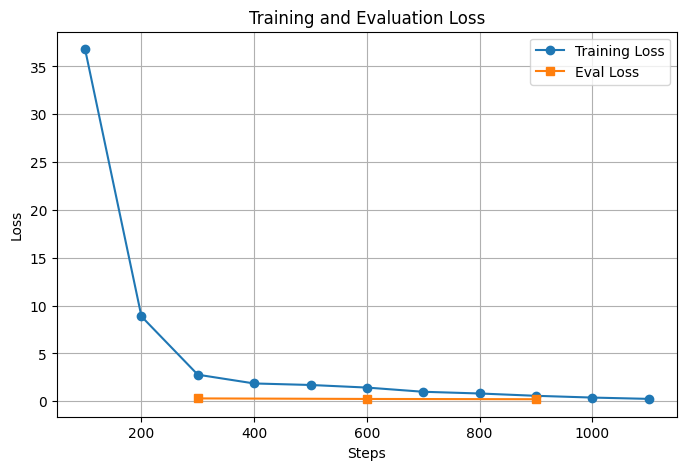

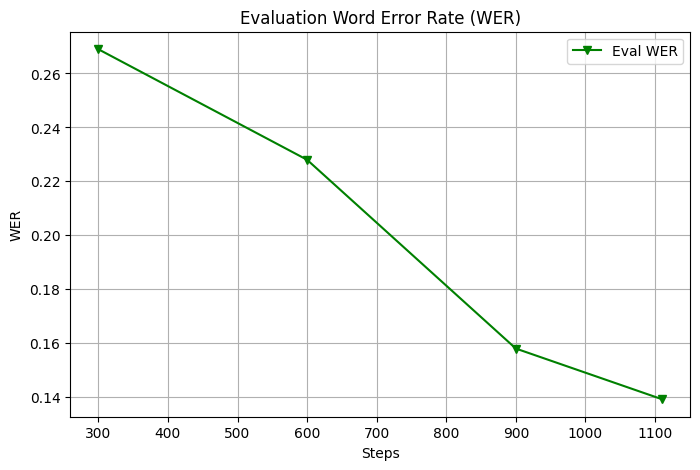

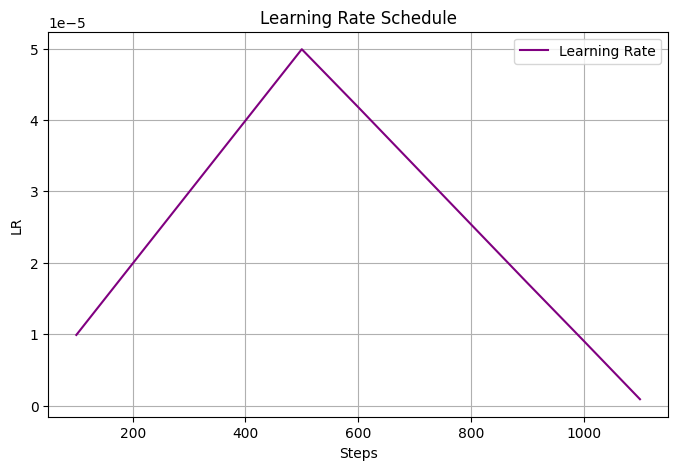

In [53]:
import json
import matplotlib.pyplot as plt

# Data from trainer_state.json
data = {
  "log_history": [
    {"epoch": 0.90, "learning_rate": 9.9e-06, "loss": 36.796, "step": 100},
    {"epoch": 1.80, "learning_rate": 1.99e-05, "loss": 8.864, "step": 200},
    {"epoch": 2.70, "learning_rate": 2.99e-05, "loss": 2.774, "step": 300},
    {"epoch": 2.70, "eval_loss": 0.296, "eval_wer": 0.269, "step": 300},
    {"epoch": 3.60, "learning_rate": 3.99e-05, "loss": 1.859, "step": 400},
    {"epoch": 4.50, "learning_rate": 4.99e-05, "loss": 1.700, "step": 500},
    {"epoch": 5.40, "learning_rate": 4.18e-05, "loss": 1.429, "step": 600},
    {"epoch": 5.40, "eval_loss": 0.240, "eval_wer": 0.228, "step": 600},
    {"epoch": 6.30, "learning_rate": 3.36e-05, "loss": 0.990, "step": 700},
    {"epoch": 7.20, "learning_rate": 2.54e-05, "loss": 0.810, "step": 800},
    {"epoch": 8.10, "learning_rate": 1.72e-05, "loss": 0.568, "step": 900},
    {"epoch": 8.10, "eval_loss": 0.211, "eval_wer": 0.158, "step": 900},
    {"epoch": 9.00, "learning_rate": 9.09e-06, "loss": 0.384, "step": 1000},
    {"epoch": 9.91, "learning_rate": 9.01e-07, "loss": 0.247, "step": 1100}
  ]
}

# Extraction
train_steps, train_loss, lr = [], [], []
eval_steps, eval_loss, eval_wer = [], [], []

for entry in data['log_history']:
    step = entry.get('step')
    if 'eval_loss' in entry:
        eval_steps.append(step)
        eval_loss.append(entry.get('eval_loss'))
        eval_wer.append(entry.get('eval_wer'))
    elif 'loss' in entry:
        train_steps.append(step)
        train_loss.append(entry.get('loss'))
        lr.append(entry.get('learning_rate'))

# Manual point for step 1110
manual_step = 1110
manual_wer = 0.13921172309247096
eval_steps_wer = eval_steps + [manual_step]
eval_wer_extended = eval_wer + [manual_wer]

# 1. Loss Plot
plt.figure(figsize=(8, 5))
plt.plot(train_steps, train_loss, label='Training Loss', marker='o')
plt.plot(eval_steps, eval_loss, label='Eval Loss', marker='s')
plt.title('Training and Evaluation Loss')
plt.xlabel('Steps')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.savefig('loss_plot.png')

# 2. WER Plot
plt.figure(figsize=(8, 5))
plt.plot(eval_steps_wer, eval_wer_extended, label='Eval WER', marker='v', color='green')
plt.title('Evaluation Word Error Rate (WER)')
plt.xlabel('Steps')
plt.ylabel('WER')
plt.legend()
plt.grid(True)
plt.savefig('wer_plot.png')

# 3. Learning Rate Plot
plt.figure(figsize=(8, 5))
plt.plot(train_steps, lr, label='Learning Rate', color='purple')
plt.title('Learning Rate Schedule')
plt.xlabel('Steps')
plt.ylabel('LR')
plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))
plt.legend()
plt.grid(True)
plt.savefig('lr_plot.png')

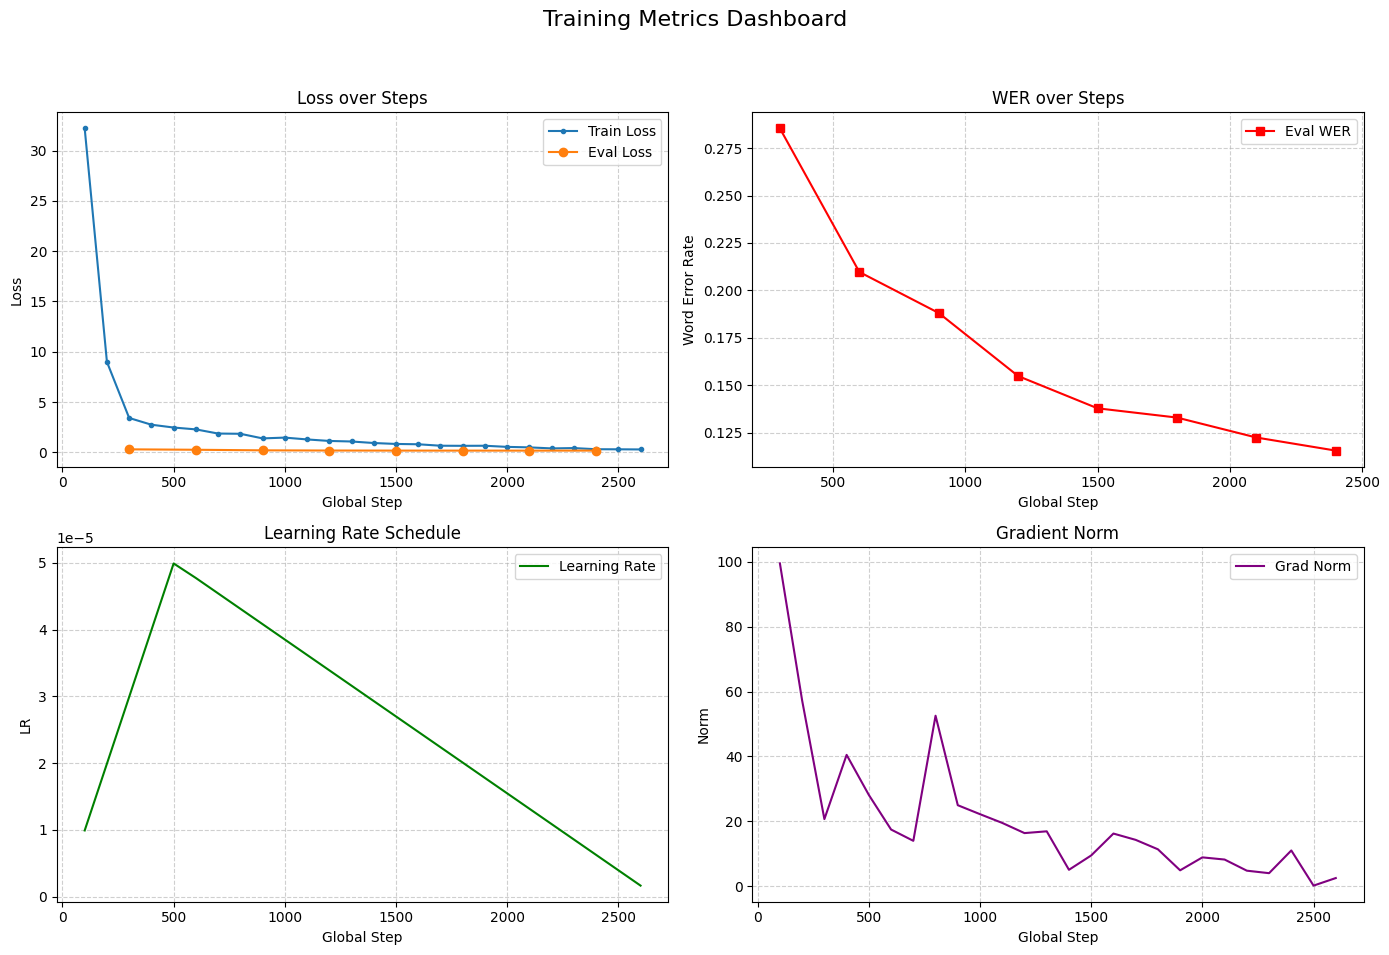

In [1]:
import json
import matplotlib.pyplot as plt
import pandas as pd

def plot_trainer_state(file_path):
    # 1. Load the JSON data
    with open(file_path, 'r') as f:
        data = json.load(f)
    
    history = data['log_history']
    
    # 2. Separate Training and Evaluation logs
    # Training logs usually have 'loss', while Eval logs have 'eval_loss'
    train_logs = [log for log in history if 'loss' in log]
    eval_logs = [log for log in history if 'eval_loss' in log]
    
    df_train = pd.DataFrame(train_logs)
    df_eval = pd.DataFrame(eval_logs)
    
    # 3. Create the plots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('Training Metrics Dashboard', fontsize=16)

    # Plot 1: Loss (Training vs Evaluation)
    axes[0, 0].plot(df_train['step'], df_train['loss'], label='Train Loss', marker='.')
    if not df_eval.empty:
        axes[0, 0].plot(df_eval['step'], df_eval['eval_loss'], label='Eval Loss', marker='o')
    axes[0, 0].set_title('Loss over Steps')
    axes[0, 0].set_xlabel('Global Step')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.6)

    # Plot 2: Word Error Rate (WER)
    if 'eval_wer' in df_eval.columns:
        axes[0, 1].plot(df_eval['step'], df_eval['eval_wer'], label='Eval WER', color='red', marker='s')
        axes[0, 1].set_title('WER over Steps')
        axes[0, 1].set_xlabel('Global Step')
        axes[0, 1].set_ylabel('Word Error Rate')
        axes[0, 1].legend()
        axes[0, 1].grid(True, linestyle='--', alpha=0.6)

    # Plot 3: Learning Rate
    axes[1, 0].plot(df_train['step'], df_train['learning_rate'], label='Learning Rate', color='green')
    axes[1, 0].set_title('Learning Rate Schedule')
    axes[1, 0].set_xlabel('Global Step')
    axes[1, 0].set_ylabel('LR')
    axes[1, 0].legend()
    axes[1, 0].grid(True, linestyle='--', alpha=0.6)

    # Plot 4: Gradient Norm
    axes[1, 1].plot(df_train['step'], df_train['grad_norm'], label='Grad Norm', color='purple')
    axes[1, 1].set_title('Gradient Norm')
    axes[1, 1].set_xlabel('Global Step')
    axes[1, 1].set_ylabel('Norm')
    axes[1, 1].legend()
    axes[1, 1].grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
    # To save: plt.savefig('training_report.png')

# Usage
file_path = r'C:\Users\Ian\Documents\TeziTesting\Runs\run4\checkpoint-2670\trainer_state.json'
plot_trainer_state(file_path)

In [22]:
from pyctcdecode import build_ctcdecoder
import torch
from transformers import Wav2Vec2BertForCTC, Wav2Vec2BertProcessor

In [22]:
# Paths
project_root = Path.home() / "MalteseProject"
MODEL_PATH = project_root / "Runs" / "run4" / "checkpoint-2670"
LM_PATH = project_root / "3_correct2.bin"

MODEL_PATH = str(MODEL_PATH)
LM_PATH = str(LM_PATH)

device = "cuda" if torch.cuda.is_available() else "cpu"

# Load the components
processor = Wav2Vec2BertProcessor.from_pretrained(MODEL_PATH)
model = Wav2Vec2BertForCTC.from_pretrained(MODEL_PATH).to(device)

In [23]:
processor = Wav2Vec2BertProcessor.from_pretrained(MODEL_PATH)
model = Wav2Vec2BertForCTC.from_pretrained(MODEL_PATH).to(device)

In [24]:
# Extract and sort the vocabulary
vocab = processor.tokenizer.get_vocab()
sorted_vocab = [k for k, v in sorted(vocab.items(), key=lambda item: item[1])]

# Specifically for Wav2Vec2 models, check if the "pipe" character is used for space
# If your model uses '|' for spaces, it's already handled in the sorted_vocab

In [11]:
import torch
import librosa
from pathlib import Path
from transformers import Wav2Vec2BertForCTC, Wav2Vec2BertProcessor
from pyctcdecode import build_ctcdecoder
from jiwer import wer
from tqdm import tqdm

# 1. Setup paths
base_path = Path(".") 
my_model_path = base_path / "Runs" / "SplitRunReduced" / "checkpoint-2780"
LM_PATH = str(base_path / "4_tok_pros.bin")

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load Model and Processor
model = Wav2Vec2BertForCTC.from_pretrained(my_model_path).to(device)
processor = Wav2Vec2BertProcessor.from_pretrained(my_model_path)
model.eval()

# 3. Prepare Decoder Vocab
vocab = processor.tokenizer.get_vocab()
sorted_vocab = [k for k, v in sorted(vocab.items(), key=lambda item: item[1])]


ARPA_PATH = str(base_path / "3_tok_pros.arpa") # Path to  ARPA file

# 1. Extract Unigrams 
def get_unigram_list(arpa_path):
    unigrams = []
    with open(arpa_path, "r") as f:
        is_unigram_section = False
        for line in f:
            if "\\1-grams:" in line:
                is_unigram_section = True
                continue
            if "\\2-grams:" in line or line.startswith("\\end\\"):
                break
            if is_unigram_section:
                parts = line.strip().split()
                if len(parts) >= 2:
                    word = parts[1]
                    if word not in ["<s>", "</s>", "<unk>"]:
                        unigrams.append(word)
    return unigrams

print("Extracting unigrams...")
UNIGRAM_LIST = get_unigram_list(ARPA_PATH)

def optimize_with_dataset(dataset):
    all_logits_numpy = []
    all_ground_truths = []
    greedy_preds = []

    print(f"--- Step 1: Generating Logits for {len(dataset)} samples ---")
    
    for i in tqdm(range(len(dataset))):
        batch = dataset[i]
        # Use the logic from your attempt: Load from the 'audio' dictionary in the dataset
        audio = batch["audio"]["array"] 
        
        # 4. Convert audio to format the model expects (Your Step 5 logic)
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(device)

        # 5. Run Inference (Your Step 6 logic)
        with torch.no_grad():
            logits = model(input_features).logits
        
        # Store for KenLM
        all_logits_numpy.append(logits.cpu().numpy()[0])
        
        # Store Ground Truth
        all_ground_truths.append(batch["sentence"].lower())
        
        # Store Greedy (Your Step 7 logic)
        pred_ids = torch.argmax(logits, dim=-1)
        greedy_preds.append(processor.batch_decode(pred_ids)[0].lower())

    # Calculate Baseline WER
    baseline_wer = wer(all_ground_truths, greedy_preds)
    print(f"\nRAW MODEL WER: {baseline_wer:.4f}")

    # 6. Grid Search for Alpha and Beta
    best_wer = 1.0
    best_params = (0, 0)
    
    # Expanded ranges to find the true minimum
    alphas = [0.3, 0.5, 0.7, 0.9, 1.1] 
    betas = [1.0, 2.0, 3.0, 4.0, 5.0, 7.0]

    print(f"\n--- Step 2: Grid Search ({len(alphas) * len(betas)} combinations) ---")
    print(f"{'Alpha':<8} | {'Beta':<8} | {'WER':<10}")
    print("-" * 35)

    # Initialize decoder ONCE to save time and memory
    decoder = build_ctcdecoder(
        labels=sorted_vocab,
        kenlm_model_path=LM_PATH,
        unigrams=UNIGRAM_LIST,
    )

    for a in alphas:
        for b in betas:
            # Update the existing decoder's weights (fast)
            decoder.reset_params(alpha=a, beta=b)
            
            # Run the decoding
            kenlm_preds = [decoder.decode(l).lower() for l in all_logits_numpy]
            current_wer = wer(all_ground_truths, kenlm_preds)
            
            print(f"{a:<8} | {b:<8} | {current_wer:.4f}")
            
            if current_wer < best_wer:
                best_wer = current_wer
                best_params = (a, b)
    
    return best_params

Extracting unigrams...


#### Redcued, fourgram

In [12]:
best_a, best_b = optimize_with_dataset(common_voice_dev)

--- Step 1: Generating Logits for 1883 samples ---


100%|██████████| 1883/1883 [03:26<00:00,  9.12it/s]
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?



RAW MODEL WER: 0.1722

--- Step 2: Grid Search (30 combinations) ---
Alpha    | Beta     | WER       
-----------------------------------
0.3      | 1.0      | 0.1375
0.3      | 2.0      | 0.1408
0.3      | 3.0      | 0.1492
0.3      | 4.0      | 0.1652
0.3      | 5.0      | 0.1913
0.3      | 7.0      | 0.2634
0.5      | 1.0      | 0.1335
0.5      | 2.0      | 0.1324
0.5      | 3.0      | 0.1351
0.5      | 4.0      | 0.1444
0.5      | 5.0      | 0.1625
0.5      | 7.0      | 0.2159
0.7      | 1.0      | 0.1359
0.7      | 2.0      | 0.1334
0.7      | 3.0      | 0.1316
0.7      | 4.0      | 0.1329
0.7      | 5.0      | 0.1401
0.7      | 7.0      | 0.1815
0.9      | 1.0      | 0.1418
0.9      | 2.0      | 0.1388
0.9      | 3.0      | 0.1352
0.9      | 4.0      | 0.1330
0.9      | 5.0      | 0.1337
0.9      | 7.0      | 0.1559
1.1      | 1.0      | 0.1542
1.1      | 2.0      | 0.1496
1.1      | 3.0      | 0.1442
1.1      | 4.0      | 0.1396
1.1      | 5.0      | 0.1372
1.1      | 7.0      

#### Reduced, trigram, actual split, tokenised + unigrams

In [14]:
best_a, best_b = optimize_with_dataset(common_voice_dev)

--- Step 1: Generating Logits for 1883 samples ---


100%|██████████| 1883/1883 [03:18<00:00,  9.49it/s]
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?



RAW MODEL WER: 0.1722

--- Step 2: Grid Search (30 combinations) ---
Alpha    | Beta     | WER       
-----------------------------------
0.3      | 1.0      | 0.1374
0.3      | 2.0      | 0.1406
0.3      | 3.0      | 0.1479
0.3      | 4.0      | 0.1649
0.3      | 5.0      | 0.1925
0.3      | 7.0      | 0.2605
0.5      | 1.0      | 0.1331
0.5      | 2.0      | 0.1328
0.5      | 3.0      | 0.1358
0.5      | 4.0      | 0.1433
0.5      | 5.0      | 0.1607
0.5      | 7.0      | 0.2135
0.7      | 1.0      | 0.1361
0.7      | 2.0      | 0.1337
0.7      | 3.0      | 0.1314
0.7      | 4.0      | 0.1333
0.7      | 5.0      | 0.1399
0.7      | 7.0      | 0.1814
0.9      | 1.0      | 0.1425
0.9      | 2.0      | 0.1390
0.9      | 3.0      | 0.1357
0.9      | 4.0      | 0.1333
0.9      | 5.0      | 0.1339
0.9      | 7.0      | 0.1563
1.1      | 1.0      | 0.1532
1.1      | 2.0      | 0.1488
1.1      | 3.0      | 0.1440
1.1      | 4.0      | 0.1401
1.1      | 5.0      | 0.1369
1.1      | 7.0      

##### Reduced Vocabulary with actual spliuts, tokenised and 4 grams.

In [17]:
best_a, best_b = optimize_with_dataset(common_voice_dev)

--- Step 1: Generating Logits for 1883 samples ---


100%|██████████| 1883/1883 [02:57<00:00, 10.61it/s]
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.



RAW MODEL WER: 0.1722

Alpha    | Beta     | WER       
-----------------------------------


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.85     | 2.0      | 0.1429
0.85     | 3.0      | 0.1398


...

0.9      | 3.0      | 0.1413
0.9      | 4.0      | 0.1402


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 2.0      | 0.1465
0.95     | 3.0      | 0.1433


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 4.0      | 0.1417

--- Optimization Result ---
Best Alpha: 0.85
Best Beta:  4.0
Best WER:   0.1394 (Reduction of 0.0328)


#### W2v tokenised but with actual data splits

In [24]:
best_a, best_b = optimize_with_dataset(common_voice_dev)

--- Step 1: Generating Logits for 1883 samples ---


100%|██████████| 1883/1883 [02:50<00:00, 11.04it/s]
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.



RAW MODEL WER: 0.1709

Alpha    | Beta     | WER       
-----------------------------------


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.85     | 2.0      | 0.1435
0.85     | 3.0      | 0.1401


...

0.95     | 2.0      | 0.1468


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 3.0      | 0.1442


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 4.0      | 0.1409

--- Optimization Result ---
Best Alpha: 0.85
Best Beta:  4.0
Best WER:   0.1384 (Reduction of 0.0325)


#### Standard w2v2-bert + LM

In [ ]:
best_a, best_b = optimize_with_dataset(common_voice_test)

--- Step 1: Generating Logits for 1660 samples ---


100%|██████████| 1660/1660 [02:36<00:00, 10.60it/s]
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.



RAW MODEL WER: 0.1390

Alpha    | Beta     | WER       
-----------------------------------


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.85     | 2.0      | 0.0979
0.85     | 3.0      | 0.0974


...

0.9      | 4.0      | 0.0980


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 2.0      | 0.0996


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 3.0      | 0.0992
0.95     | 4.0      | 0.0979

--- Optimization Result ---
Best Alpha: 0.9
Best Beta:  3.0
Best WER:   0.0973 (Reduction of 0.0417)


#### Tokenised w2v2-bert + lm

In [17]:
best_a, best_b = optimize_with_dataset(common_voice_test)

--- Step 1: Generating Logits for 1660 samples ---


100%|██████████| 1660/1660 [02:35<00:00, 10.67it/s]



RAW MODEL WER: 0.1256

Alpha    | Beta     | WER       
-----------------------------------


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.85     | 2.0      | 0.0886
0.85     | 3.0      | 0.0880


...

0.9      | 4.0      | 0.0881
0.95     | 2.0      | 0.0898


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 3.0      | 0.0886


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 4.0      | 0.0878

--- Optimization Result ---
Best Alpha: 0.95
Best Beta:  4.0
Best WER:   0.0878 (Reduction of 0.0378)


### Tokenised + Processed

In [15]:
best_a, best_b = optimize_with_dataset(common_voice_test)

--- Step 1: Generating Logits for 1660 samples ---


100%|██████████| 1660/1660 [02:58<00:00,  9.32it/s]
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.



RAW MODEL WER: 0.1256

Alpha    | Beta     | WER       
-----------------------------------
0.85     | 2.0      | 0.0889


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.85     | 3.0      | 0.0880


...

0.9      | 4.0      | 0.0882


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 2.0      | 0.0896


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 3.0      | 0.0885
0.95     | 4.0      | 0.0878

--- Optimization Result ---
Best Alpha: 0.95
Best Beta:  4.0
Best WER:   0.0878 (Reduction of 0.0378)


### Vanilla CV+MASRI W2v2 + Highly Processed KenLM

In [27]:
# Run with the new kenlm. The rest used the older one
best_a, best_b = optimize_with_dataset(common_voice_test)

--- Step 1: Generating Logits for 1660 samples ---


100%|██████████| 1660/1660 [03:06<00:00,  8.90it/s]
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.



RAW MODEL WER: 0.1141

Alpha    | Beta     | WER       
-----------------------------------


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.85     | 2.0      | 0.0808


...

0.9      | 3.0      | 0.0808


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.9      | 4.0      | 0.0812
0.95     | 2.0      | 0.0814


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 3.0      | 0.0809
0.95     | 4.0      | 0.0812

--- Optimization Result ---
Best Alpha: 0.85
Best Beta:  3.0
Best WER:   0.0807 (Reduction of 0.0334)


In [38]:
# Run the process
best_a, best_b = optimize_with_dataset(common_voice_test)

--- Step 1: Generating Logits for 1660 samples ---


100%|██████████| 1660/1660 [02:39<00:00, 10.41it/s]
Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.



RAW MODEL WER: 0.1141

Alpha    | Beta     | WER       
-----------------------------------


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.85     | 2.0      | 0.0807
0.85     | 3.0      | 0.0805


...

0.95     | 2.0      | 0.0812


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 3.0      | 0.0806


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 4.0      | 0.0809

--- Optimization Result ---
Best Alpha: 0.85
Best Beta:  3.0
Best WER:   0.0805 (Reduction of 0.0336)


In [36]:
# Run the optimization
train_subset = common_voice_train.shuffle(seed=42).select(range(2000))

# Run the same optimization function on this subset
best_alpha_train, best_beta_train = optimize_with_dataset(train_subset)

print(f"Parameters tuned on Train: Alpha {best_alpha_train}, Beta {best_beta_train}")

--- Step 1: Generating Logits for 2000 samples ---


100%|██████████| 2000/2000 [02:52<00:00, 11.62it/s]



RAW MODEL WER: 0.0370

Alpha    | Beta     | WER       
-----------------------------------


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.85     | 2.0      | 0.0396


...

0.95     | 2.0      | 0.0411


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 3.0      | 0.0407


Unigrams not provided and cannot be automatically determined from LM file (only arpa format). Decoding accuracy might be reduced.
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?
No known unigrams provided, decoding results might be a lot worse.


0.95     | 4.0      | 0.0404

--- Optimization Result ---
Best Alpha: 0.85
Best Beta:  4.0
Best WER:   0.0393 (Reduction of -0.0023)
Parameters tuned on Train: Alpha 0.85, Beta 4.0


#### Raw Model

In [13]:
import torch
from pathlib import Path
from transformers import Wav2Vec2BertForCTC, Wav2Vec2BertProcessor
from jiwer import wer, cer  # <--- Added cer import
from tqdm import tqdm

# 1. Setup
base_path = Path(".") 
my_model_path = base_path / "Runs" / "SplitRunReduced" / "checkpoint-2780"
device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load Model and Processor
model = Wav2Vec2BertForCTC.from_pretrained(my_model_path).to(device)
processor = Wav2Vec2BertProcessor.from_pretrained(my_model_path)
model.eval()

def evaluate_raw_model(dataset):
    all_ground_truths = []
    greedy_preds = []

    print(f"--- Evaluating {len(dataset)} samples (Greedy Decoding) ---")
    
    for i in tqdm(range(len(dataset))):
        batch = dataset[i]
        audio = batch["audio"]["array"] 
        
        # Preprocess
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(device)

        # Inference
        with torch.no_grad():
            logits = model(input_features).logits
        
        # Greedy Decode (Argmax)
        pred_ids = torch.argmax(logits, dim=-1)
        transcription = processor.batch_decode(pred_ids)[0]
        
        # Store results
        greedy_preds.append(transcription.lower())
        all_ground_truths.append(batch["sentence"].lower())

    # --- Metrics Calculation ---
    final_wer = wer(all_ground_truths, greedy_preds)
    final_cer = cer(all_ground_truths, greedy_preds)
    
    print("\n" + "="*35)
    print(f"RAW MODEL RESULTS:")
    print(f"WER: {final_wer:.4f} ({final_wer*100:.2f}%)")
    print(f"CER: {final_cer:.4f} ({final_cer*100:.2f}%)")
    print("="*35)
    
    # Sanity Check
    print("\nSample Transcriptions:")
    for j in range(min(2, len(all_ground_truths))):
        print(f"REF: {all_ground_truths[j]}")
        print(f"HYP: {greedy_preds[j]}")
        print("-" * 10)

    return {"wer": final_wer, "cer": final_cer}

In [23]:
evaluate_raw_model(common_voice_test) #CV+MASRI

--- Evaluating 1892 samples (Greedy Decoding) ---


100%|██████████| 1892/1892 [02:52<00:00, 10.96it/s]



RAW MODEL RESULTS:
WER: 0.1816 (18.16%)
CER: 0.0575 (5.75%)

Sample Transcriptions:
REF: maskarat tini perlina għax warajk għandek xadina minflok waħda tini tnejn biex warajk ma jkollok xejn
HYP: maskarat ini perlina għax warajk għandek x' għdina minflok waħda tini tnejn ix warajk ma jkollok xejn
----------
REF: eħe f' dan is- suġġett se nagħtu ħarsa lejn in- novelli u r- rumanzi tal- awturi maltin kosmopolitani jiġifieri li bdew jiktbu
HYP: eħe f' dan is- suġġett se nagħtu ħarsa lejn n- novelli u r- rumanzi ta' l- awturi maltin kosmopolitan jiġifieri bdew jiktbu
----------


{'wer': 0.18158334599604922, 'cer': 0.05749326951839665}

In [19]:
evaluate_raw_model(masri_test)

--- Evaluating 668 samples (Greedy Decoding) ---


100%|██████████| 668/668 [01:11<00:00,  9.28it/s]


RAW MODEL RESULTS:
WER: 0.2894 (28.94%)
CER: 0.0989 (9.89%)

Sample Transcriptions:
REF: maskarat tini perlina għax warajk għandek xadina minflok waħda tini tnejn biex warajk ma jkollok xejn
HYP: maskerattini perlina għax warajk għandek xadina minflok waħda tini - tnejn għiex warajk ma jkollok xejn
----------
REF: eħe f' dan is- suġġett se nagħtu ħarsa lejn in- novelli u r- rumanzi tal- awturi maltin kosmopolitani jiġifieri li bdew jiktbu
HYP: eħe f' dan is- suġġett se nagħtu ħarsa lejn in-novelli u r- rumanzi ta' l- awturi maltin kosmopolitan jiġifierili bdew jiktbu
----------


{'wer': 0.28939313984168863, 'cer': 0.0989193083573487}

#### With LM

In [ ]:
import torch
from pathlib import Path
from transformers import Wav2Vec2BertForCTC, Wav2Vec2BertProcessor
from pyctcdecode import build_ctcdecoder
from jiwer import wer, cer
from tqdm import tqdm

# 1. Setup paths
base_path = Path(".") 
my_model_path = base_path / "Runs" / "SplitRunReduced" / "checkpoint-2780"
LM_PATH = str(base_path / "5_tok_pros.bin")

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load Model and Processor
model = Wav2Vec2BertForCTC.from_pretrained(my_model_path).to(device)
processor = Wav2Vec2BertProcessor.from_pretrained(my_model_path)
model.eval()

# 3. Prepare Decoder Vocab
vocab = processor.tokenizer.get_vocab()
sorted_vocab = [k for k, v in sorted(vocab.items(), key=lambda item: item[1])]

def evaluate_kenlm_manual(dataset, alpha=0.85, beta=4.0):
    all_logits_numpy = []
    all_ground_truths = []
    greedy_preds = []

    print(f"--- Step 1: Generating Logits for {len(dataset)} samples ---")
    
    for i in tqdm(range(len(dataset))):
        batch = dataset[i]
        audio = batch["audio"]["array"] 
        
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(device)

        with torch.no_grad():
            logits = model(input_features).logits
        
        all_logits_numpy.append(logits.cpu().numpy()[0])
        all_ground_truths.append(batch["sentence"].lower())
        
        pred_ids = torch.argmax(logits, dim=-1)
        greedy_preds.append(processor.batch_decode(pred_ids)[0].lower())

    # Calculate Raw Metrics
    baseline_wer = wer(all_ground_truths, greedy_preds)
    baseline_cer = cer(all_ground_truths, greedy_preds)

    # --- Step 2: Decode with fixed KenLM parameters ---
    print(f"\n--- Step 2: Decoding with KenLM (Alpha: {alpha}, Beta: {beta}) ---")
    
    decoder = build_ctcdecoder(
        labels=sorted_vocab,
        kenlm_model_path=LM_PATH,
        alpha=alpha,
        beta=beta
    )
    
    kenlm_preds = [decoder.decode(l).lower() for l in all_logits_numpy]
    kenlm_wer = wer(all_ground_truths, kenlm_preds)
    kenlm_cer = cer(all_ground_truths, kenlm_preds)

    # --- Final Results ---
    print("\n" + "="*45)
    print(f"{'Metric':<10} | {'Raw Model':<12} | {'With KenLM':<12}")
    print("-" * 45)
    print(f"{'WER':<10} | {baseline_wer:<12.4f} | {kenlm_wer:<12.4f}")
    print(f"{'CER':<10} | {baseline_cer:<12.4f} | {kenlm_cer:<12.4f}")
    print("="*45)
    
    improvement = baseline_wer - kenlm_wer
    print(f"\nWER Improvement: {improvement:.4f}")
    
    return {"raw_wer": baseline_wer, "kenlm_wer": kenlm_wer}

In [7]:
import torch
from pathlib import Path
from transformers import Wav2Vec2BertForCTC, Wav2Vec2BertProcessor
from pyctcdecode import build_ctcdecoder
from jiwer import wer, cer
from tqdm import tqdm

# 1. Setup paths
base_path = Path(".") 
my_model_path = base_path / "Runs" / "SplitRunReduced" / "checkpoint-2780"
LM_PATH = str(base_path / "3_tok_pros.bin")
ARPA_PATH = str(base_path / "3_tok_pros.arpa") # We need the text version for unigrams

device = "cuda" if torch.cuda.is_available() else "cpu"

# 2. Load Model and Processor
model = Wav2Vec2BertForCTC.from_pretrained(my_model_path).to(device)
processor = Wav2Vec2BertProcessor.from_pretrained(my_model_path)
model.eval()

# 3. Prepare Decoder Vocab
vocab = processor.tokenizer.get_vocab()
sorted_vocab = [k for k, v in sorted(vocab.items(), key=lambda item: item[1])]

# --- NEW: Extract unigrams from ARPA to pass into the binary decoder ---
def get_unigram_list(arpa_path):
    unigrams = []
    with open(arpa_path, "r") as f:
        is_unigram_section = False
        for line in f:
            if "\\1-grams:" in line:
                is_unigram_section = True
                continue
            if "\\2-grams:" in line or line.startswith("\\end\\"):
                break
            if is_unigram_section:
                parts = line.strip().split()
                if len(parts) >= 2:
                    word = parts[1]
                    if word not in ["<s>", "</s>", "<unk>"]:
                        unigrams.append(word)
    return unigrams

print("Extracting unigrams...")
unigrams = get_unigram_list(ARPA_PATH)
# -----------------------------------------------------------------------

Extracting unigrams...


In [8]:
def evaluate_kenlm_manual(dataset, alpha=0.85, beta=4.0):
    all_logits_numpy = []
    all_ground_truths = []
    greedy_preds = []

    print(f"--- Step 1: Generating Logits for {len(dataset)} samples ---")
    
    for i in tqdm(range(len(dataset))):
        batch = dataset[i]
        audio = batch["audio"]["array"] 
        
        inputs = processor(audio, sampling_rate=16000, return_tensors="pt")
        input_features = inputs.input_features.to(device)

        with torch.no_grad():
            logits = model(input_features).logits
        
        all_logits_numpy.append(logits.cpu().numpy()[0])
        all_ground_truths.append(batch["sentence"].lower())
        
        pred_ids = torch.argmax(logits, dim=-1)
        greedy_preds.append(processor.batch_decode(pred_ids)[0].lower())

    # Calculate Raw Metrics
    baseline_wer = wer(all_ground_truths, greedy_preds)
    baseline_cer = cer(all_ground_truths, greedy_preds)

    # --- Step 2: Decode with fixed KenLM parameters ---
    print(f"\n--- Step 2: Decoding with KenLM (Alpha: {alpha}, Beta: {beta}) ---")
    
    # UPDATED: Added 'unigrams' argument
    decoder = build_ctcdecoder(
        labels=sorted_vocab,
        kenlm_model_path=LM_PATH,
        unigrams=unigrams, # <--- Crucial fix
        alpha=alpha,
        beta=beta
    )
    
    kenlm_preds = [decoder.decode(l).lower() for l in all_logits_numpy]
    kenlm_wer = wer(all_ground_truths, kenlm_preds)
    kenlm_cer = cer(all_ground_truths, kenlm_preds)

    # --- Final Results ---
    print("\n" + "="*45)
    print(f"{'Metric':<10} | {'Raw Model':<12} | {'With KenLM':<12}")
    print("-" * 45)
    print(f"{'WER':<10} | {baseline_wer:<12.4f} | {kenlm_wer:<12.4f}")
    print(f"{'CER':<10} | {baseline_cer:<12.4f} | {kenlm_cer:<12.4f}")
    print("="*45)
    
    improvement = baseline_wer - kenlm_wer
    print(f"\nWER Improvement: {improvement:.4f}")
    
    return {"raw_wer": baseline_wer, "kenlm_wer": kenlm_wer}

In [12]:
results = evaluate_kenlm_manual(common_voice_test, alpha=0.7, beta=3.0)

--- Step 1: Generating Logits for 1892 samples ---


100%|██████████| 1892/1892 [02:56<00:00, 10.71it/s]
Found entries of length > 1 in alphabet. This is unusual unless style is BPE, but the alphabet was not recognized as BPE type. Is this correct?



--- Step 2: Decoding with KenLM (Alpha: 0.7, Beta: 3.0) ---

Metric     | Raw Model    | With KenLM  
---------------------------------------------
WER        | 0.1834       | 0.1458      
CER        | 0.0579       | 0.0552      

WER Improvement: 0.0376


Alright! The transcription can definitely be recognized from our prediction, but it is not perfect yet. Training the model a bit longer, spending more time on the data preprocessing, and especially using a language model for decoding would certainly improve the model's overall performance.

For a demonstration model on a low-resource language, the results are quite acceptable however 🤗.


## Scaling-up the training

We've shown in this blogpost how Meta's `w2v-bert-2.0` fine-tuning can give near state-of-the-art performance on low-resource languages.

To take things a step further, I've put together a set of tips and pointers given by my colleagues at Hugging Face on how to scale up training for this model. Many thanks to [Patrick](https://huggingface.co/patrickvonplaten), [Sanchit](https://huggingface.co/sanchit-gandhi) and [Pablo](https://huggingface.co/Molbap) for their valuable expertise and help 🤗

Note that Common Voice newest version ([CV16](https://huggingface.co/datasets/mozilla-foundation/common_voice_16_0)) provides many more hours of data and for may languages and thus provides fertile ground for much more efficient models in many low-resource languages.


### Datasets-related tips

CTC ASR is typically done with lower-case, un-punctuated transcriptions. This simplifies the CTC task since the model is considered as "acoustic only", meaning that it makes prediction largely based on the phonetics sounds of the audio, rather than any language modelling context of the spoken sentence.

Very low-frequency characters can significantly affect loss during learning by causing loss spikes via erroneous targets. By default, the CTC tokenizer created in this blog post would add them to the vocabulary even if their frequency is negligible compared to more frequent characters. We can treat these characters as "errors" in the dataset annotation, so that they can be removed from the vocabulary, and simply classified as `"[UNK]"` during training.

It is therefore absolutely necessary to recheck the tokenizer vocabulary and remove all low-frequency characters, in much the same way as we removed Latin characters when creating the tokenizer.

Note that the Common Voice dataset is particularly prone to such "wrong" characters, for example characters from other languages (阪).

### Training-related tips

**Average duration seen by each CTC token:** According to the advice of my colleagues, the ideal ratio of duration seen per CTC token is 10 to 35 ms. In other words, to be able to learn and predict correctly, the duration of the acoustic information a CTC token needs to see should be neither too low nor too high. In fact, it should more or less correspond to a fraction of the time it takes us humans to pronounce a phoneme.

This is something that came to light when I started refining this new W2V2-Bert model (you can find the logs of one of my experiments [here](https://wandb.ai/ylacombe/huggingface/runs/4y8pd2gq)). I quickly noticed that the loss curve of my model was initially going nicely downwards, as expected, but at some point it started to explode.

After discussing this with my colleagues, I realized that I had been using a [basic checkpoint with no architecture changes](https://huggingface.co/facebook/w2v-bert-2.0), and that each CTC token was seeing a piece of the signal for 30 to 60 ms. Adding an adapter layer was enough to reduce the signal chunk sampling to the desired duration.


**Under-training:** After showing this blog post [training run](https://huggingface.co/hf-audio/w2v-bert-2.0-mongolian-colab-CV16.0#training-results) and another [training attempt](https://wandb.ai/ylacombe/huggingface/runs/nasaux7f?workspace=user-ylacombe) on English Common Voice (about 2.5k validated hours) to my colleagues, they pointed out that the model was severely under-trained, something that could have been spotted by looking at the loss curve, which looks like it was stopped in the middle of a steep descent. This pointed out other issues as well, notably the loss curve not being smooth enough, a sign of wrong hyper-parameters settings.

Here are a few ways to solve under-training in our case:
- the warm-up rate might be too high, causing the learning rate to drop too quickly. A way to solve this would be keep the warmup ratio to 5 to 15% and scale up the number of epochs. The warm-up steps are essential to gradually bring the new language-model head weights into alignment with the pre-trained model.
- Loss curve lack of smoothness can be played around thanks to [AdamW](https://pytorch.org/docs/stable/generated/torch.optim.AdamW.html)'s [\\( \beta_2 \\)](https://huggingface.co/docs/transformers/main_classes/trainer#transformers.TrainingArguments.adam_beta2) which can typically set from 0.95 to 0.98 by default.




*Related posts and additional links are listed here:*
- [**Official paper**](https://huggingface.co/papers/2305.13516)
- [**Original cobebase**](https://ai.meta.com/research/publications/seamless-multilingual-expressive-and-streaming-speech-translation/)
- [**Transformers Docs**](https://huggingface.co/docs/transformers/main/en/model_doc/wav2vec2-bert)
- [**Related XLS-R blog post**](https://huggingface.co/blog/fine-tune-xlsr-wav2vec2)
- [**Related MMS blog post**](https://huggingface.co/blog/mms_adapters)
